# Gradient Boosting Ensemble: 3 Boosters x 4 Sub-Models

Features from `main_0.135.py` (~126), architecture from `boosting.ipynb` (4 sub-models x 3 boosters).

In [1]:
from pathlib import Path
import os
import gc
import json as _json
import warnings
from typing import List, Dict

import numpy as np
import pandas as pd
import polars as pl

from sklearn.metrics import average_precision_score
from scipy.stats import rankdata
from scipy.optimize import minimize
from scipy.special import softmax
from catboost import CatBoostClassifier, Pool
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings("ignore")
pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(200)

# --- Paths ---
DATA_DIR = Path("data/raw")
BOOST_CACHE_DIR = Path("cache/boosting")
SUBMISSION_DIR = Path("submission_boosting")
BOOST_CACHE_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

# --- Sampling ---
NEG_SAMPLE_MOD_RECENT = 10   # from 2025-04-01
NEG_SAMPLE_MOD_OLD = 30      # before 2025-04-01
NEG_SAMPLE_BORDER_STR = "2025-04-01 00:00:00"

# --- Validation ---
VAL_START = pd.Timestamp("2025-05-01")
RECENT_BORDER = pd.Timestamp("2025-02-01")
RECENCY_WEIGHT_START = pd.Timestamp("2025-02-01")

# --- Refit ---
REFIT_ITER_MULT = 1.10

# --- Flags ---
RANDOM_SEED = 67
FORCE_REBUILD_FEATURES = False
FORCE_REBUILD_PRIORS = False
ADD_CATEGORY_PRIORS = True
USE_GPU = True

# --- Training control ---
# Set to False to skip train/val fitting and load cached models + metadata
TRAIN_CB = True       # CatBoost train/val (cell 13)
TRAIN_LGB = True      # LightGBM train/val (cell 16)
TRAIN_XGB = True      # XGBoost train/val (cell 19)

# --- Refit control ---
RETRAIN_ON_FULL_CB = True
RETRAIN_ON_FULL_LGB = True
RETRAIN_ON_FULL_XGB = True

# --- GPU check ---
try:
    import torch
    if torch.cuda.is_available():
        gpu = torch.cuda.get_device_properties(0)
        vram_gb = gpu.total_memory / 1024**3
        print(f"GPU: {gpu.name}, VRAM: {vram_gb:.1f} GB")
    else:
        print("CUDA not available, will use CPU")
        USE_GPU = False
except ImportError:
    print("torch not installed, GPU check skipped")

print("DATA_DIR:", DATA_DIR.resolve())
print("CACHE_DIR:", BOOST_CACHE_DIR.resolve())

GPU: NVIDIA GeForce RTX 3060 Ti, VRAM: 8.0 GB
DATA_DIR: D:\prog\ml\data_fusion\local_df\data\raw
CACHE_DIR: D:\prog\ml\data_fusion\local_df\cache\boosting


In [2]:
# ==================== UTILITY FUNCTIONS ====================

def sigmoid(x):
    x = np.clip(x, -40, 40)
    return 1.0 / (1.0 + np.exp(-x))

def logit(p):
    p = np.clip(p, 1e-8, 1 - 1e-8)
    return np.log(p / (1 - p))

def to_logit(pred, is_probability=True):
    if is_probability:
        return logit(pred)
    return pred

def make_weights(raw_target, event_ts=None):
    """Sample weights: red=10, yellow=2.5, green=1.0 + recency boost."""
    w = np.where(raw_target == 1, 10.0, np.where(raw_target == 0, 2.5, 1.0)).astype(np.float32)
    if event_ts is not None:
        ts = pd.to_datetime(event_ts)
        w[ts >= RECENCY_WEIGHT_START] *= 1.15
    return w

def downcast_pandas(df, cat_cols_set=None):
    if cat_cols_set is None:
        cat_cols_set = set()
    for c in df.select_dtypes(include=['int64', 'int32']).columns:
        if c in cat_cols_set:
            continue
        col_min, col_max = df[c].min(), df[c].max()
        if pd.isna(col_min):
            continue
        if col_min >= -128 and col_max <= 127:
            df[c] = df[c].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            df[c] = df[c].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            df[c] = df[c].astype(np.int32)
    for c in df.select_dtypes(include=['float64']).columns:
        df[c] = df[c].astype(np.float32)
    return df

def rank_norm(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x)
    return rankdata(x, method="average") / (len(x) + 1.0)

def optimize_blend_weights(heads: Dict[str, np.ndarray], y_true: np.ndarray):
    """Nelder-Mead optimization with softmax weights - works with any number of models."""
    keys = list(heads.keys())
    preds = [heads[k] for k in keys]

    def neg_ap(logits):
        w = softmax(logits)
        blend = sum(w[i] * preds[i] for i in range(len(keys)))
        return -average_precision_score(y_true, blend)

    x0 = np.zeros(len(keys), dtype=np.float64)
    res = minimize(neg_ap, x0, method="Nelder-Mead",
                   options={"maxiter": 1500, "xatol": 1e-4, "fatol": 1e-6})

    best_w = softmax(res.x).astype(np.float32)
    best_ap = float(-res.fun)
    return keys, best_w, best_ap

def dedupe(items):
    seen = set()
    out = []
    for x in items:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

def _lgb_prepare(X: pd.DataFrame, cat_cols: List[str]) -> pd.DataFrame:
    Xc = X.copy()
    for col in cat_cols:
        Xc[col] = Xc[col].fillna(-1).astype(np.int64) + 1
    return Xc

print("Utilities loaded.")

Utilities loaded.


In [3]:
# ==================== COLUMN DEFINITIONS ====================

BASE_COLS = [
    "customer_id", "event_id", "event_dttm", "event_type_nm", "event_desc",
    "channel_indicator_type", "channel_indicator_sub_type", "operaton_amt",
    "currency_iso_cd", "mcc_code", "pos_cd", "timezone", "session_id",
    "operating_system_type", "battery", "device_system_version", "screen_size",
    "developer_tools", "phone_voip_call_state", "web_rdp_connection",
    "compromised", "accept_language", "browser_language",
]

FINAL_FEATURE_COLS = dedupe([
    # raw categorical
    "customer_id", "event_type_nm", "event_desc",
    "channel_indicator_type", "channel_indicator_sub_type",
    "currency_iso_cd", "mcc_code_i", "pos_cd", "timezone",
    "operating_system_type", "phone_voip_call_state", "web_rdp_connection",
    "developer_tools_i", "compromised_i",
    "accept_language_i", "browser_language_i", "device_fp_i",
    # missingness flags
    "amt_missing", "currency_missing", "mcc_missing", "pos_missing",
    "tz_missing", "os_missing", "battery_missing", "dev_ver_missing",
    "screen_missing", "dev_tools_missing", "voip_missing", "rdp_missing",
    "compromised_missing", "accept_lang_missing", "browser_lang_missing",
    "session_missing",
    # event numeric
    "amt", "amt_log_abs", "amt_is_negative", "amt_abs", "amt_bucket",
    "hour", "weekday", "day", "month",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
    "is_weekend", "is_night", "event_day_number", "battery_pct",
    "os_ver_major", "screen_w", "screen_h", "screen_pixels", "screen_ratio",
    "session_id",
    # account age
    "days_since_first_event", "cust_active_days", "avg_prev_events_per_active_day",
    # sequence
    "cust_prev_events", "cust_prev_amt_mean", "cust_prev_amt_std",
    "cust_prev_max_amt", "amt_vs_personal_max", "amt_zscore",
    "sec_since_prev_event", "amt_delta_prev",
    "cnt_prev_same_type", "cnt_prev_same_desc", "cnt_prev_same_mcc",
    "cnt_prev_same_subtype", "cnt_prev_same_session",
    "cnt_prev_same_channel_type", "cnt_prev_same_currency", "cnt_prev_same_device",
    "sec_since_prev_same_type", "sec_since_prev_same_desc",
    "events_before_today",
    # session
    "sec_since_session_start", "session_amt_before",
    # first-time flags
    "is_new_event_type", "is_new_event_desc", "is_new_channel_sub",
    "is_new_mcc", "is_new_pos", "is_new_tz", "is_new_os", "is_new_currency",
    # rolling windows
    "amt_sum_last_1h", "cnt_last_1h",
    "amt_sum_last_24h", "cnt_last_24h", "max_amt_last_24h",
    # dynamic feedback history (strictly from previous labeled events)
    "cust_prev_red_lbl_cnt", "cust_prev_yellow_lbl_cnt", "cust_prev_labeled_cnt",
    "cust_prev_red_lbl_rate", "cust_prev_yellow_lbl_rate", "cust_prev_susp_lbl_rate",
    "cust_prev_any_red_flag", "cust_prev_any_yellow_flag",
    "sec_since_prev_red_lbl", "sec_since_prev_yellow_lbl",
    "cnt_prev_labeled_same_desc", "cnt_prev_red_same_desc_lbl",
    "cnt_prev_yellow_same_desc_lbl", "red_rate_prev_same_desc_lbl",
    # fine-grained label history
    "cnt_prev_labeled_same_channel", "cnt_prev_red_same_channel_lbl",
    "red_rate_prev_same_channel_lbl",
    "cnt_prev_labeled_same_type", "cnt_prev_red_same_type_lbl",
    "red_rate_prev_same_type_lbl",
])

CAT_COLS = [
    "customer_id", "event_type_nm", "event_desc",
    "channel_indicator_type", "channel_indicator_sub_type",
    "currency_iso_cd", "mcc_code_i", "pos_cd", "timezone",
    "operating_system_type", "phone_voip_call_state", "web_rdp_connection",
    "developer_tools_i", "compromised_i",
    "accept_language_i", "browser_language_i", "device_fp_i",
]

MODEL_DROP_COLS = {"target", "keep_green", "event_date", "event_hour_trunc", "month", "event_day_number", "session_id"}

META_COLS = ["event_id", "period", "event_ts", "is_train_sample", "is_test", "train_target_raw", "target_bin"]

labels_lf = pl.scan_parquet(DATA_DIR / "train_labels.parquet")
labels_df = pl.read_parquet(DATA_DIR / "train_labels.parquet")
print("Labels:", labels_df.shape)
print("FINAL_FEATURE_COLS:", len(FINAL_FEATURE_COLS))
print("CAT_COLS:", len(CAT_COLS))

Labels: (87514, 3)
FINAL_FEATURE_COLS: 115
CAT_COLS: 17


In [4]:
# ==================== FEATURE ENGINEERING ====================
# All features computed in Polars via .over() window functions (no pandas groupby).
# Customers are processed in chunks to limit memory usage.

FEATURE_CHUNK_SIZE = 3000  # customers per chunk


def _device_fp_expr_from_raw():
    """Composite device fingerprint from os + screen + dev_ver."""
    return (
        pl.col("operating_system_type").cast(pl.Utf8).fill_null("?")
        + "|" + pl.col("screen_size").cast(pl.Utf8).fill_null("?")
        + "|" + pl.col("device_system_version").cast(pl.Utf8).fill_null("?")
    ).hash(seed=0).cast(pl.Int32, strict=False).alias("device_fp_i")


def _load_periods_for_chunk(part_id: int, cust_series: pl.Series) -> pl.LazyFrame:
    """Load pretrain+train+pretest+test for a SUBSET of customers."""
    pretrain_lf = (
        pl.scan_parquet(DATA_DIR / f"pretrain_part_{part_id}.parquet")
        .filter(pl.col("customer_id").is_in(cust_series))
        .select(BASE_COLS)
        .with_columns(pl.lit("pretrain").alias("period"))
    )
    train_lf = (
        pl.scan_parquet(DATA_DIR / f"train_part_{part_id}.parquet")
        .filter(pl.col("customer_id").is_in(cust_series))
        .select(BASE_COLS)
        .with_columns(pl.lit("train").alias("period"))
    )
    pretest_lf = (
        pl.scan_parquet(DATA_DIR / "pretest.parquet")
        .filter(pl.col("customer_id").is_in(cust_series))
        .select(BASE_COLS)
        .unique()  # FIX: 130,360 duplicate rows in pretest
        .with_columns(pl.lit("pretest").alias("period"))
    )
    test_lf = (
        pl.scan_parquet(DATA_DIR / "test.parquet")
        .filter(pl.col("customer_id").is_in(cust_series))
        .select(BASE_COLS)
        .with_columns(pl.lit("test").alias("period"))
    )
    return pl.concat([pretrain_lf, train_lf, pretest_lf, test_lf], how="vertical_relaxed")


def _build_features_for_chunk(lf: pl.LazyFrame) -> pl.DataFrame:
    """Build all ~126 features for a chunk. Returns collected DataFrame of train+test rows only."""

    # ---- Parse raw columns ----
    lf = lf.with_columns([
        pl.col("event_dttm").str.strptime(
            pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False
        ).alias("event_ts"),
        pl.col("operaton_amt").cast(pl.Float64).alias("amt"),
        pl.col("session_id").cast(pl.Int64, strict=False).fill_null(-1).alias("session_id"),

        pl.col("event_type_nm").cast(pl.Int32, strict=False).fill_null(-1).alias("event_type_nm"),
        pl.col("event_desc").cast(pl.Int32, strict=False).fill_null(-1).alias("event_desc"),
        pl.col("channel_indicator_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_type"),
        pl.col("channel_indicator_sub_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_sub_type"),
        pl.col("currency_iso_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("currency_iso_cd"),
        pl.col("pos_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("pos_cd"),
        pl.col("timezone").cast(pl.Int32, strict=False).fill_null(-1).alias("timezone"),
        pl.col("operating_system_type").cast(pl.Int16, strict=False).fill_null(-1).alias("operating_system_type"),
        pl.col("phone_voip_call_state").cast(pl.Int8, strict=False).fill_null(-1).alias("phone_voip_call_state"),
        pl.col("web_rdp_connection").cast(pl.Int8, strict=False).fill_null(-1).alias("web_rdp_connection"),

        pl.col("mcc_code").cast(pl.Int32, strict=False).fill_null(-1).alias("mcc_code_i"),
        pl.col("developer_tools").cast(pl.Int8, strict=False).fill_null(-1).alias("developer_tools_i"),
        pl.col("compromised").cast(pl.Int8, strict=False).fill_null(-1).alias("compromised_i"),
        pl.col("accept_language").cast(pl.Int32, strict=False).fill_null(-1).alias("accept_language_i"),
        pl.col("browser_language").cast(pl.Int32, strict=False).fill_null(-1).alias("browser_language_i"),

        _device_fp_expr_from_raw(),
    ])

    # ---- Missingness flags ----
    lf = lf.with_columns([
        pl.col("operaton_amt").is_null().cast(pl.Int8).alias("amt_missing"),
        pl.col("currency_iso_cd").is_null().cast(pl.Int8).alias("currency_missing"),
        pl.col("mcc_code").is_null().cast(pl.Int8).alias("mcc_missing"),
        pl.col("pos_cd").is_null().cast(pl.Int8).alias("pos_missing"),
        pl.col("timezone").is_null().cast(pl.Int8).alias("tz_missing"),
        pl.col("operating_system_type").is_null().cast(pl.Int8).alias("os_missing"),
        pl.col("battery").is_null().cast(pl.Int8).alias("battery_missing"),
        pl.col("device_system_version").is_null().cast(pl.Int8).alias("dev_ver_missing"),
        pl.col("screen_size").is_null().cast(pl.Int8).alias("screen_missing"),
        pl.col("developer_tools").is_null().cast(pl.Int8).alias("dev_tools_missing"),
        pl.col("phone_voip_call_state").is_null().cast(pl.Int8).alias("voip_missing"),
        pl.col("web_rdp_connection").is_null().cast(pl.Int8).alias("rdp_missing"),
        pl.col("compromised").is_null().cast(pl.Int8).alias("compromised_missing"),
        pl.col("accept_language").is_null().cast(pl.Int8).alias("accept_lang_missing"),
        pl.col("browser_language").is_null().cast(pl.Int8).alias("browser_lang_missing"),
        pl.col("session_id").is_null().cast(pl.Int8).alias("session_missing"),
    ])

    # ---- Drop raw columns no longer needed ----
    lf = lf.drop([
        "event_dttm", "operaton_amt", "mcc_code", "battery",
        "device_system_version", "screen_size", "developer_tools",
        "compromised", "accept_language", "browser_language",
    ])

    # ---- Numeric features ----
    lf = lf.with_columns([
        pl.col("amt").fill_null(0.0),
        pl.col("amt").abs().alias("amt_abs"),
        pl.col("amt").abs().log1p().cast(pl.Float32).alias("amt_log_abs"),
        (pl.col("amt") < 0).cast(pl.Int8).alias("amt_is_negative"),
        pl.col("amt").abs().log1p().cast(pl.Int8).alias("amt_bucket"),

        pl.col("event_ts").dt.hour().cast(pl.Int8).alias("hour"),
        pl.col("event_ts").dt.weekday().cast(pl.Int8).alias("weekday"),
        pl.col("event_ts").dt.day().cast(pl.Int8).alias("day"),
        pl.col("event_ts").dt.month().cast(pl.Int8).alias("month"),
        (pl.col("event_ts").dt.weekday() >= 5).cast(pl.Int8).alias("is_weekend"),
        pl.col("event_ts").dt.date().alias("event_date"),
        pl.col("event_ts").dt.truncate("1h").alias("event_hour_trunc"),
    ])

    # ---- Circular temporal ----
    lf = lf.with_columns([
        (pl.col("hour").cast(pl.Float32) * 2.0 * np.pi / 24.0).sin().alias("hour_sin"),
        (pl.col("hour").cast(pl.Float32) * 2.0 * np.pi / 24.0).cos().alias("hour_cos"),
        (pl.col("weekday").cast(pl.Float32) * 2.0 * np.pi / 7.0).sin().alias("weekday_sin"),
        (pl.col("weekday").cast(pl.Float32) * 2.0 * np.pi / 7.0).cos().alias("weekday_cos"),
        (pl.col("month").cast(pl.Float32) * 2.0 * np.pi / 12.0).sin().alias("month_sin"),
        (pl.col("month").cast(pl.Float32) * 2.0 * np.pi / 12.0).cos().alias("month_cos"),
        ((pl.col("hour") >= 22) | (pl.col("hour") <= 5)).cast(pl.Int8).alias("is_night"),
    ])

    # ---- Screen, battery, os ----
    lf = lf.with_columns([
        (pl.col("event_ts").dt.epoch("s") // 86400).cast(pl.Int16).alias("event_day_number"),
        pl.col("screen_w").fill_null(0),
        pl.col("screen_h").fill_null(0),
    ]) if False else lf  # placeholder — screen_w/h already parsed? No, we dropped screen_size above.

    # screen features from raw — need to re-extract since we dropped screen_size
    # Actually we need to extract BEFORE dropping. Let me restructure.
    # The screen_w/h, battery_pct, os_ver_major were extracted in the original code
    # but we dropped the raw columns. Let me add them to the initial parse block.

    # We need to go back and add these to the initial parse. But since this is a lazy frame,
    # let me just check — they should already be in the initial parse block... No, they aren't.
    # Let me add them. Actually, the initial block doesn't parse screen/battery/os_ver.
    # I need to add them before the drop.

    # This is getting complex. Let me restructure: parse ALL derived columns BEFORE dropping raws.
    # But we already dropped. So I need to move the screen/battery/os parsing before the drop.

    # SOLUTION: Don't drop raw columns yet, parse everything first, then drop at the end.
    # But we already have the drop above. Let me remove it and restructure.

    # Actually, the simpler fix: move screen/battery/os parsing into the initial parse block.
    # Let me just add them there. But we already wrote the initial block...
    # For now, since this is a complete rewrite, let me restructure properly.

    # I realize the issue — I need to restructure this whole function.
    # Let me start fresh with proper ordering.
    pass


# Actually, let me rewrite this function properly from scratch.
# The above attempt has structural issues. Here's the clean version:

def _build_features_for_chunk_v2(lf: pl.LazyFrame) -> pl.DataFrame:
    """Build all ~126 features for a chunk in pure Polars. Returns train+test rows only."""

    # ===== STEP 1: Parse all raw columns =====
    lf = lf.with_columns([
        pl.col("event_dttm").str.strptime(
            pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False
        ).alias("event_ts"),
        pl.col("operaton_amt").cast(pl.Float64).alias("amt"),
        pl.col("session_id").cast(pl.Int64, strict=False).fill_null(-1).alias("session_id"),

        # categoricals
        pl.col("event_type_nm").cast(pl.Int32, strict=False).fill_null(-1).alias("event_type_nm"),
        pl.col("event_desc").cast(pl.Int32, strict=False).fill_null(-1).alias("event_desc"),
        pl.col("channel_indicator_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_type"),
        pl.col("channel_indicator_sub_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_sub_type"),
        pl.col("currency_iso_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("currency_iso_cd"),
        pl.col("pos_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("pos_cd"),
        pl.col("timezone").cast(pl.Int32, strict=False).fill_null(-1).alias("timezone"),
        pl.col("operating_system_type").cast(pl.Int16, strict=False).fill_null(-1).alias("operating_system_type"),
        pl.col("phone_voip_call_state").cast(pl.Int8, strict=False).fill_null(-1).alias("phone_voip_call_state"),
        pl.col("web_rdp_connection").cast(pl.Int8, strict=False).fill_null(-1).alias("web_rdp_connection"),

        pl.col("mcc_code").cast(pl.Int32, strict=False).fill_null(-1).alias("mcc_code_i"),
        pl.col("developer_tools").cast(pl.Int8, strict=False).fill_null(-1).alias("developer_tools_i"),
        pl.col("compromised").cast(pl.Int8, strict=False).fill_null(-1).alias("compromised_i"),
        pl.col("accept_language").cast(pl.Int32, strict=False).fill_null(-1).alias("accept_language_i"),
        pl.col("browser_language").cast(pl.Int32, strict=False).fill_null(-1).alias("browser_language_i"),
        _device_fp_expr_from_raw(),

        # missingness flags (must be computed BEFORE dropping raw columns)
        pl.col("operaton_amt").is_null().cast(pl.Int8).alias("amt_missing"),
        pl.col("currency_iso_cd").is_null().cast(pl.Int8).alias("currency_missing"),
        pl.col("mcc_code").is_null().cast(pl.Int8).alias("mcc_missing"),
        pl.col("pos_cd").is_null().cast(pl.Int8).alias("pos_missing"),
        pl.col("timezone").is_null().cast(pl.Int8).alias("tz_missing"),
        pl.col("operating_system_type").is_null().cast(pl.Int8).alias("os_missing"),
        pl.col("battery").is_null().cast(pl.Int8).alias("battery_missing"),
        pl.col("device_system_version").is_null().cast(pl.Int8).alias("dev_ver_missing"),
        pl.col("screen_size").is_null().cast(pl.Int8).alias("screen_missing"),
        pl.col("developer_tools").is_null().cast(pl.Int8).alias("dev_tools_missing"),
        pl.col("phone_voip_call_state").is_null().cast(pl.Int8).alias("voip_missing"),
        pl.col("web_rdp_connection").is_null().cast(pl.Int8).alias("rdp_missing"),
        pl.col("compromised").is_null().cast(pl.Int8).alias("compromised_missing"),
        pl.col("accept_language").is_null().cast(pl.Int8).alias("accept_lang_missing"),
        pl.col("browser_language").is_null().cast(pl.Int8).alias("browser_lang_missing"),
        pl.col("session_id").is_null().cast(pl.Int8).alias("session_missing"),

        # battery, screen, os_ver (extract before dropping raws)
        pl.col("battery").cast(pl.Float32, strict=False).fill_null(-1.0).alias("battery_pct"),
        pl.col("device_system_version").cast(pl.Utf8).str.extract(r"^(\d+)", 1)
          .cast(pl.Int16, strict=False).fill_null(-1).alias("os_ver_major"),
        pl.col("screen_size").str.extract(r"^(\d+)", 1)
          .cast(pl.Int16, strict=False).fill_null(0).alias("screen_w"),
        pl.col("screen_size").str.extract(r"x(\d+)", 1)
          .cast(pl.Int16, strict=False).fill_null(0).alias("screen_h"),
    ])

    # Drop raw columns
    lf = lf.drop([
        "event_dttm", "operaton_amt", "mcc_code", "battery",
        "device_system_version", "screen_size", "developer_tools",
        "compromised", "accept_language", "browser_language",
    ])

    # ===== STEP 2: Numeric, temporal, screen =====
    lf = lf.with_columns([
        pl.col("amt").fill_null(0.0),
        pl.col("amt").abs().alias("amt_abs"),
        pl.col("amt").abs().log1p().cast(pl.Float32).alias("amt_log_abs"),
        (pl.col("amt") < 0).cast(pl.Int8).alias("amt_is_negative"),
        pl.col("amt").abs().log1p().cast(pl.Int8).alias("amt_bucket"),

        pl.col("event_ts").dt.hour().cast(pl.Int8).alias("hour"),
        pl.col("event_ts").dt.weekday().cast(pl.Int8).alias("weekday"),
        pl.col("event_ts").dt.day().cast(pl.Int8).alias("day"),
        pl.col("event_ts").dt.month().cast(pl.Int8).alias("month"),
        (pl.col("event_ts").dt.weekday() >= 5).cast(pl.Int8).alias("is_weekend"),
        pl.col("event_ts").dt.date().alias("event_date"),
        pl.col("event_ts").dt.truncate("1h").alias("event_hour_trunc"),
        (pl.col("event_ts").dt.epoch("s") // 86400).cast(pl.Int16).alias("event_day_number"),
    ])

    # circular temporal
    lf = lf.with_columns([
        (pl.col("hour").cast(pl.Float32) * 2.0 * np.pi / 24.0).sin().alias("hour_sin"),
        (pl.col("hour").cast(pl.Float32) * 2.0 * np.pi / 24.0).cos().alias("hour_cos"),
        (pl.col("weekday").cast(pl.Float32) * 2.0 * np.pi / 7.0).sin().alias("weekday_sin"),
        (pl.col("weekday").cast(pl.Float32) * 2.0 * np.pi / 7.0).cos().alias("weekday_cos"),
        (pl.col("month").cast(pl.Float32) * 2.0 * np.pi / 12.0).sin().alias("month_sin"),
        (pl.col("month").cast(pl.Float32) * 2.0 * np.pi / 12.0).cos().alias("month_cos"),
        ((pl.col("hour") >= 22) | (pl.col("hour") <= 5)).cast(pl.Int8).alias("is_night"),
    ])

    # screen derived
    lf = lf.with_columns([
        pl.when((pl.col("screen_w") > 0) & (pl.col("screen_h") > 0))
          .then(pl.col("screen_w").cast(pl.Int32) * pl.col("screen_h").cast(pl.Int32))
          .otherwise(-1).alias("screen_pixels"),
        pl.when(pl.col("screen_h") > 0)
          .then(pl.col("screen_w").cast(pl.Float32) / pl.col("screen_h").cast(pl.Float32))
          .otherwise(0.0).cast(pl.Float32).alias("screen_ratio"),
    ])

    # ===== STEP 3: Sort for window functions =====
    lf = lf.sort(["customer_id", "event_ts", "event_id"])

    # ===== STEP 4: Join labels =====
    lf = lf.join(labels_lf, on="event_id", how="left")
    lf = lf.with_columns(
        pl.when(pl.col("period") == "train")
          .then(
              pl.when(pl.col("target").is_null())
                .then(pl.lit(-1))
                .otherwise(pl.col("target"))
          )
          .otherwise(pl.lit(None))
          .alias("train_target_raw")
    )

    # ===== STEP 5: Negative sampling & flags =====
    border_expr = pl.lit(NEG_SAMPLE_BORDER_STR).str.strptime(
        pl.Datetime, format="%Y-%m-%d %H:%M:%S", strict=False
    )
    lf = lf.with_columns(
        (
            (pl.col("period") == "train")
            & (pl.col("train_target_raw") == -1)
            & (
                (
                    (pl.col("event_ts") >= border_expr)
                    & ((pl.col("event_id").hash(seed=RANDOM_SEED) % NEG_SAMPLE_MOD_RECENT) == 0)
                ) | (
                    (pl.col("event_ts") < border_expr)
                    & ((pl.col("event_id").hash(seed=RANDOM_SEED) % NEG_SAMPLE_MOD_OLD) == 0)
                )
            )
        ).alias("keep_green")
    )
    lf = lf.with_columns([
        (
            (pl.col("period") == "train")
            & ((pl.col("train_target_raw") != -1) | pl.col("keep_green"))
        ).alias("is_train_sample"),
        (pl.col("period") == "test").alias("is_test"),
        (pl.col("train_target_raw") == 1).fill_null(False).cast(pl.Int8).alias("target_bin"),
    ])

    # ===== STEP 6: Sequential features via .over() =====
    lf = lf.with_columns([
        # event index within customer
        pl.cum_count("event_id").over("customer_id").cast(pl.Int32).alias("_cust_idx"),
        # cumulative amt
        pl.col("amt").cum_sum().over("customer_id").alias("_cust_cum_amt"),
        (pl.col("amt") * pl.col("amt")).cum_sum().over("customer_id").alias("_cust_cum_amt_sq"),
        # previous event
        pl.col("event_ts").shift(1).over("customer_id").alias("_prev_ts"),
        pl.col("amt").shift(1).over("customer_id").alias("_prev_amt"),
        # cumulative max
        pl.col("amt").cum_max().over("customer_id").alias("_cust_cum_max_incl"),
        # first event ts
        pl.col("event_ts").min().over("customer_id").alias("_cust_first_ts"),
        # active days (approximate — unique dates seen so far not easily done in polars,
        # so we use total unique for the customer as proxy)
        pl.col("event_date").n_unique().over("customer_id").cast(pl.Int16).alias("cust_active_days"),

        # count prev same-X
        (pl.cum_count("event_id").over(["customer_id", "event_type_nm"]) - 1).cast(pl.Int16).alias("cnt_prev_same_type"),
        (pl.cum_count("event_id").over(["customer_id", "event_desc"]) - 1).cast(pl.Int16).alias("cnt_prev_same_desc"),
        (pl.cum_count("event_id").over(["customer_id", "mcc_code_i"]) - 1).cast(pl.Int16).alias("cnt_prev_same_mcc"),
        (pl.cum_count("event_id").over(["customer_id", "channel_indicator_sub_type"]) - 1).cast(pl.Int16).alias("cnt_prev_same_subtype"),
        (pl.cum_count("event_id").over(["customer_id", "session_id"]) - 1).cast(pl.Int16).alias("cnt_prev_same_session"),
        (pl.cum_count("event_id").over(["customer_id", "channel_indicator_type"]) - 1).cast(pl.Int16).alias("cnt_prev_same_channel_type"),
        (pl.cum_count("event_id").over(["customer_id", "currency_iso_cd"]) - 1).cast(pl.Int16).alias("cnt_prev_same_currency"),
        (pl.cum_count("event_id").over(["customer_id", "device_fp_i"]) - 1).cast(pl.Int16).alias("cnt_prev_same_device"),

        # prev same-type/desc timestamps
        pl.col("event_ts").shift(1).over(["customer_id", "event_type_nm"]).alias("_prev_same_type_ts"),
        pl.col("event_ts").shift(1).over(["customer_id", "event_desc"]).alias("_prev_same_desc_ts"),

        # events before today
        (pl.cum_count("event_id").over(["customer_id", "event_date"]) - 1).cast(pl.Int16).alias("events_before_today"),

        # session features
        pl.col("event_ts").min().over(["customer_id", "session_id"]).alias("_session_start_ts"),
        pl.col("amt").cum_sum().over(["customer_id", "session_id"]).alias("_session_cum_amt"),

        # label columns for history
        pl.col("target").fill_null(-999).alias("_lbl"),
    ])

    # ===== STEP 7: Derived sequential features =====
    lf = lf.with_columns([
        (pl.col("_cust_idx") - 1).cast(pl.Int32).alias("cust_prev_events"),

        # prev amt mean
        pl.when(pl.col("_cust_idx") > 1)
          .then((pl.col("_cust_cum_amt") - pl.col("amt")) / (pl.col("_cust_idx") - 1))
          .otherwise(0.0).cast(pl.Float32).alias("cust_prev_amt_mean"),

        # sec since prev event
        pl.when(pl.col("_prev_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("_prev_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Float32).alias("sec_since_prev_event"),

        # amt delta
        (pl.col("amt") - pl.col("_prev_amt").fill_null(0.0)).cast(pl.Float32).alias("amt_delta_prev"),

        # sec since prev same type/desc
        pl.when(pl.col("_prev_same_type_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("_prev_same_type_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Float32).alias("sec_since_prev_same_type"),
        pl.when(pl.col("_prev_same_desc_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("_prev_same_desc_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Float32).alias("sec_since_prev_same_desc"),

        # account age
        pl.when(pl.col("_cust_first_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("_cust_first_ts")).dt.total_days())
          .otherwise(0).cast(pl.Float32).alias("days_since_first_event"),

        # avg prev events per active day
        pl.when(pl.col("cust_active_days") > 0)
          .then((pl.col("_cust_idx") - 1).cast(pl.Float32) / pl.col("cust_active_days").cast(pl.Float32))
          .otherwise(0.0).cast(pl.Float32).alias("avg_prev_events_per_active_day"),

        # prev max amt (shifted)
        pl.col("_cust_cum_max_incl").shift(1).over("customer_id").alias("cust_prev_max_amt"),

        # session features
        (pl.col("event_ts") - pl.col("_session_start_ts")).dt.total_seconds()
          .fill_null(0).cast(pl.Float32).alias("sec_since_session_start"),
        (pl.col("_session_cum_amt") - pl.col("amt")).fill_null(0).cast(pl.Float32).alias("session_amt_before"),
    ])

    # ---- Running std ----
    lf = lf.with_columns(
        pl.when(pl.col("_cust_idx") > 2)
          .then(
              (
                  (pl.col("_cust_cum_amt_sq") - pl.col("amt") * pl.col("amt"))
                  / (pl.col("_cust_idx") - 1)
                  - pl.col("cust_prev_amt_mean") ** 2
              ).clip(lower_bound=0).sqrt()
          )
          .otherwise(0.0).cast(pl.Float32).alias("cust_prev_amt_std")
    )

    # amt_zscore, amt_vs_personal_max
    lf = lf.with_columns([
        pl.when(pl.col("cust_prev_amt_std") > 0)
          .then((pl.col("amt") - pl.col("cust_prev_amt_mean")) / (pl.col("cust_prev_amt_std") + 1e-6))
          .otherwise(0.0).cast(pl.Float32).alias("amt_zscore"),

        pl.when(pl.col("cust_prev_max_amt").is_not_null() & (pl.col("cust_prev_max_amt").abs() > 1e-6))
          .then(pl.col("amt") / (pl.col("cust_prev_max_amt") + 1e-6))
          .otherwise(0.0).cast(pl.Float32).alias("amt_vs_personal_max"),
    ])

    # ===== STEP 8: First-time flags =====
    lf = lf.with_columns([
        (pl.col("cnt_prev_same_type") == 0).cast(pl.Int8).alias("is_new_event_type"),
        (pl.col("cnt_prev_same_desc") == 0).cast(pl.Int8).alias("is_new_event_desc"),
        (pl.col("cnt_prev_same_subtype") == 0).cast(pl.Int8).alias("is_new_channel_sub"),
        (pl.col("cnt_prev_same_mcc") == 0).cast(pl.Int8).alias("is_new_mcc"),
        (pl.cum_count("event_id").over(["customer_id", "pos_cd"]) == 1).cast(pl.Int8).alias("is_new_pos"),
        (pl.cum_count("event_id").over(["customer_id", "timezone"]) == 1).cast(pl.Int8).alias("is_new_tz"),
        (pl.cum_count("event_id").over(["customer_id", "operating_system_type"]) == 1).cast(pl.Int8).alias("is_new_os"),
        (pl.col("cnt_prev_same_currency") == 0).cast(pl.Int8).alias("is_new_currency"),
    ])

    # ===== STEP 9: Velocity features via join_asof (1h, 24h) =====
    _vel_right = lf.select([
        pl.col("customer_id"),
        pl.col("event_ts").alias("_ref_ts"),
        pl.col("_cust_idx").alias("_ref_cidx"),
        pl.col("_cust_cum_amt").alias("_ref_cum_amt"),
    ])

    for period_min, cnt_col, sum_col, max_col in [
        (60,   "cnt_last_1h",  "amt_sum_last_1h",  None),
        (1440, "cnt_last_24h", "amt_sum_last_24h", "max_amt_last_24h"),
    ]:
        _vel_left = lf.select([
            "customer_id", "event_id",
            (pl.col("event_ts") - pl.duration(minutes=period_min)).alias("_ts_ago"),
            pl.col("_cust_idx"),
            pl.col("_cust_cum_amt"),
            pl.col("amt"),
        ])
        _vel_joined = _vel_left.join_asof(
            _vel_right,
            left_on="_ts_ago",
            right_on="_ref_ts",
            by="customer_id",
            strategy="backward",
        )
        agg_exprs = [
            pl.when(pl.col("_ref_cidx").is_not_null())
              .then(pl.col("_cust_idx") - pl.col("_ref_cidx") - 1)
              .otherwise(pl.col("_cust_idx") - 1)
              .cast(pl.Float32).alias(cnt_col),
            pl.when(pl.col("_ref_cum_amt").is_not_null())
              .then(pl.col("_cust_cum_amt") - pl.col("amt") - pl.col("_ref_cum_amt"))
              .otherwise(pl.col("_cust_cum_amt") - pl.col("amt"))
              .cast(pl.Float32).alias(sum_col),
        ]
        sel_cols = ["event_id", cnt_col, sum_col]
        _vel_result = _vel_joined.with_columns(agg_exprs).select(sel_cols)
        lf = lf.join(_vel_result, on="event_id", how="left")

    # max_amt_last_24h: approximate with shifted cum_max (exact rolling max is expensive)
    # Use cust_prev_max_amt as a reasonable proxy
    lf = lf.with_columns(
        pl.col("cust_prev_max_amt").fill_null(0.0).cast(pl.Float32).alias("max_amt_last_24h")
    )

    # ===== STEP 10: Label history via .over() =====
    lf = lf.with_columns([
        # cumulative red/yellow/labeled counts (shifted = strictly past)
        ((pl.col("_lbl") == 1).cast(pl.Int32).cum_sum().over("customer_id") -
         (pl.col("_lbl") == 1).cast(pl.Int32)).cast(pl.Int16).alias("cust_prev_red_lbl_cnt"),
        ((pl.col("_lbl") == 0).cast(pl.Int32).cum_sum().over("customer_id") -
         (pl.col("_lbl") == 0).cast(pl.Int32)).cast(pl.Int16).alias("cust_prev_yellow_lbl_cnt"),
        ((pl.col("_lbl") >= 0).cast(pl.Int32).cum_sum().over("customer_id") -
         (pl.col("_lbl") >= 0).cast(pl.Int32)).cast(pl.Int16).alias("cust_prev_labeled_cnt"),
    ])

    lf = lf.with_columns([
        (pl.col("cust_prev_red_lbl_cnt").cast(pl.Float32) /
         pl.col("cust_prev_labeled_cnt").clip(lower_bound=1).cast(pl.Float32)).alias("cust_prev_red_lbl_rate"),
        (pl.col("cust_prev_yellow_lbl_cnt").cast(pl.Float32) /
         pl.col("cust_prev_labeled_cnt").clip(lower_bound=1).cast(pl.Float32)).alias("cust_prev_yellow_lbl_rate"),
        ((pl.col("cust_prev_red_lbl_cnt") + pl.col("cust_prev_yellow_lbl_cnt")).cast(pl.Float32) /
         pl.col("cust_prev_labeled_cnt").clip(lower_bound=1).cast(pl.Float32)).alias("cust_prev_susp_lbl_rate"),
        (pl.col("cust_prev_red_lbl_cnt") > 0).cast(pl.Int8).alias("cust_prev_any_red_flag"),
        (pl.col("cust_prev_yellow_lbl_cnt") > 0).cast(pl.Int8).alias("cust_prev_any_yellow_flag"),
    ])

    # sec since prev red/yellow label (use forward-fill of label timestamps, shifted)
    lf = lf.with_columns([
        pl.when(pl.col("_lbl") == 1).then(pl.col("event_ts")).otherwise(None)
          .forward_fill().over("customer_id").shift(1).over("customer_id").alias("_prev_red_ts"),
        pl.when(pl.col("_lbl") == 0).then(pl.col("event_ts")).otherwise(None)
          .forward_fill().over("customer_id").shift(1).over("customer_id").alias("_prev_yellow_ts"),
    ])
    lf = lf.with_columns([
        pl.when(pl.col("_prev_red_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("_prev_red_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Float32).alias("sec_since_prev_red_lbl"),
        pl.when(pl.col("_prev_yellow_ts").is_not_null())
          .then((pl.col("event_ts") - pl.col("_prev_yellow_ts")).dt.total_seconds())
          .otherwise(-1).cast(pl.Float32).alias("sec_since_prev_yellow_lbl"),
    ])

    # per-desc/channel/type label history
    for grp_cols, prefix in [
        (["customer_id", "event_desc"], "same_desc"),
        (["customer_id", "channel_indicator_type"], "same_channel"),
        (["customer_id", "event_type_nm"], "same_type"),
    ]:
        lf = lf.with_columns([
            ((pl.col("_lbl") >= 0).cast(pl.Int32).cum_sum().over(grp_cols) -
             (pl.col("_lbl") >= 0).cast(pl.Int32)).cast(pl.Int16).alias(f"cnt_prev_labeled_{prefix}"),
            ((pl.col("_lbl") == 1).cast(pl.Int32).cum_sum().over(grp_cols) -
             (pl.col("_lbl") == 1).cast(pl.Int32)).cast(pl.Int16).alias(f"cnt_prev_red_{prefix}_lbl"),
        ])
        if prefix == "same_desc":
            lf = lf.with_columns(
                ((pl.col("_lbl") == 0).cast(pl.Int32).cum_sum().over(grp_cols) -
                 (pl.col("_lbl") == 0).cast(pl.Int32)).cast(pl.Int16).alias(f"cnt_prev_yellow_{prefix}_lbl"),
            )
        lf = lf.with_columns(
            (pl.col(f"cnt_prev_red_{prefix}_lbl").cast(pl.Float32) /
             pl.col(f"cnt_prev_labeled_{prefix}").clip(lower_bound=1).cast(pl.Float32)
            ).alias(f"red_rate_prev_{prefix}_lbl")
        )

    # ===== STEP 11: Drop intermediate columns, filter, select =====
    drop_cols = [c for c in [
        "_cust_idx", "_cust_cum_amt", "_cust_cum_amt_sq", "_prev_ts", "_prev_amt",
        "_cust_cum_max_incl", "_cust_first_ts", "_prev_same_type_ts", "_prev_same_desc_ts",
        "_session_start_ts", "_session_cum_amt", "_lbl", "_prev_red_ts", "_prev_yellow_ts",
        "target", "event_dttm",
    ] if c in lf.columns]

    out_cols = list(dict.fromkeys(
        ["event_id", "customer_id", "period", "event_ts", "event_date",
         "is_train_sample", "is_test", "train_target_raw", "target_bin", "keep_green"]
        + FINAL_FEATURE_COLS
    ))

    result = (
        lf.drop(drop_cols)
          .filter(pl.col("is_train_sample") | pl.col("is_test"))
    ).collect()

    # select only columns that exist
    existing_cols = [c for c in out_cols if c in result.columns]
    return result.select(existing_cols)


def build_features_for_part(part_id: int, force: bool = False) -> Path:
    """Build features for one partition, processing customers in chunks."""
    out_path = BOOST_CACHE_DIR / f"features_part_{part_id}.parquet"
    if out_path.exists() and (not force):
        print(f"[part {part_id}] use cache -> {out_path.name}")
        return out_path

    print(f"[part {part_id}] building features (chunked, {FEATURE_CHUNK_SIZE} custs/chunk)...")

    # Get all unique customer IDs for this partition
    custs = (
        pl.scan_parquet(DATA_DIR / f"pretrain_part_{part_id}.parquet")
        .select("customer_id").unique().collect()
        .get_column("customer_id").to_list()
    )
    print(f"  [part {part_id}] {len(custs):,} customers total")

    chunks = [custs[i:i+FEATURE_CHUNK_SIZE] for i in range(0, len(custs), FEATURE_CHUNK_SIZE)]
    results = []

    for ci, chunk_custs in enumerate(chunks):
        print(f"  [part {part_id}] chunk {ci+1}/{len(chunks)} "
              f"({len(chunk_custs)} custs) ...", end=" ", flush=True)

        cust_series = pl.Series("customer_id", chunk_custs)
        lf = _load_periods_for_chunk(part_id, cust_series)
        chunk_df = _build_features_for_chunk_v2(lf)

        print(f"-> {chunk_df.height:,} rows")
        results.append(chunk_df)

        del chunk_df, lf
        gc.collect()

    out_df = pl.concat(results)
    out_df.write_parquet(out_path, compression="zstd")

    n_tr = out_df.filter(pl.col("is_train_sample")).height
    n_te = out_df.filter(pl.col("is_test")).height
    print(f"  [part {part_id}] saved {out_path.name}: {out_df.shape} (train={n_tr:,}, test={n_te:,})")

    del out_df, results
    gc.collect()
    return out_path

print("Feature engineering functions defined.")

Feature engineering functions defined.


In [5]:
# ==================== PRIOR TABLES (DUAL: LOCAL + FULL) ====================

PRIOR_COL_DEFS = {
    "event_desc": pl.col("event_desc").cast(pl.Int32, strict=False).fill_null(-1).alias("event_desc"),
    "mcc_code_i": pl.col("mcc_code").cast(pl.Int32, strict=False).fill_null(-1).alias("mcc_code_i"),
    "timezone": pl.col("timezone").cast(pl.Int32, strict=False).fill_null(-1).alias("timezone"),
    "operating_system_type": pl.col("operating_system_type").cast(pl.Int16, strict=False).fill_null(-1).alias("operating_system_type"),
    "channel_indicator_sub_type": pl.col("channel_indicator_sub_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_sub_type"),
    "event_type_nm": pl.col("event_type_nm").cast(pl.Int32, strict=False).fill_null(-1).alias("event_type_nm"),
    "pos_cd": pl.col("pos_cd").cast(pl.Int16, strict=False).fill_null(-1).alias("pos_cd"),
    "channel_indicator_type": pl.col("channel_indicator_type").cast(pl.Int16, strict=False).fill_null(-1).alias("channel_indicator_type"),
    "accept_language_i": pl.col("accept_language").cast(pl.Int32, strict=False).fill_null(-1).alias("accept_language_i"),
    "browser_language_i": pl.col("browser_language").cast(pl.Int32, strict=False).fill_null(-1).alias("browser_language_i"),
    "device_fp_i": (
        pl.col("operating_system_type").cast(pl.Utf8).fill_null("?")
        + "|" + pl.col("screen_size").cast(pl.Utf8).fill_null("?")
        + "|" + pl.col("device_system_version").cast(pl.Utf8).fill_null("?")
    ).hash(seed=0).cast(pl.Int32, strict=False).alias("device_fp_i"),
}


def _scan_train_prior_source(cutoff=None):
    """Scan train parts + labels, optionally filtering by cutoff date."""
    parts = []
    for i in [1, 2, 3]:
        lf = pl.scan_parquet(DATA_DIR / f"train_part_{i}.parquet")
        if cutoff is not None:
            lf = lf.filter(
                pl.col("event_dttm").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False) < cutoff
            )
        parts.append(lf)
    return pl.concat(parts, how="vertical_relaxed")


def _make_prior_from_source(key_name: str, expr: pl.Expr, cutoff=None) -> pl.DataFrame:
    src = _scan_train_prior_source(cutoff)
    lf = src.select([pl.col("event_id"), expr])

    cnt_col = f"prior_{key_name}_cnt"
    lbl_cnt_col = f"prior_{key_name}_lbl_cnt"
    red_cnt_col = f"prior_{key_name}_red_cnt"

    total = lf.group_by(key_name).len().rename({"len": cnt_col})
    labeled = (
        lf.join(labels_lf, on="event_id", how="inner")
          .group_by(key_name)
          .agg([
              pl.len().alias(lbl_cnt_col),
              pl.sum("target").cast(pl.Float64).alias(red_cnt_col),
          ])
    )

    prior = (
        total.join(labeled, on=key_name, how="left")
             .with_columns([
                 pl.col(lbl_cnt_col).fill_null(0.0),
                 pl.col(red_cnt_col).fill_null(0.0),
             ])
             .with_columns([
                 ((pl.col(red_cnt_col) + 1.0) / (pl.col(cnt_col) + 200.0)).cast(pl.Float32).alias(f"prior_{key_name}_red_rate_all"),
                 ((pl.col(lbl_cnt_col) + 1.0) / (pl.col(cnt_col) + 200.0)).cast(pl.Float32).alias(f"prior_{key_name}_labeled_rate_all"),
                 ((pl.col(red_cnt_col) + 1.0) / (pl.col(lbl_cnt_col) + 2.0)).cast(pl.Float32).alias(f"prior_{key_name}_red_share_labeled"),
             ])
             .select([
                 key_name, cnt_col,
                 f"prior_{key_name}_red_rate_all",
                 f"prior_{key_name}_labeled_rate_all",
                 f"prior_{key_name}_red_share_labeled",
             ])
             .collect()
    )
    return prior


def build_prior_tables(tag: str, cutoff=None, force: bool = False):
    """Build all prior tables. tag='pre_val' or 'full_train'. Returns (dict, feature_cols)."""
    tables = {}
    feature_cols = []
    for key_name, expr in PRIOR_COL_DEFS.items():
        cache_path = BOOST_CACHE_DIR / f"prior_{tag}_{key_name}.parquet"
        if cache_path.exists() and not force:
            prior = pl.read_parquet(cache_path)
        else:
            print(f"Building prior [{tag}] for: {key_name}")
            prior = _make_prior_from_source(key_name, expr, cutoff=cutoff)
            prior.write_parquet(cache_path, compression="zstd")
        tables[key_name] = prior
        feature_cols.extend([c for c in prior.columns if c != key_name])
    return tables, feature_cols


def build_device_stats_table(tag: str, cutoff=None, force: bool = False) -> pl.DataFrame:
    """Device-level aggregation stats."""
    cache_path = BOOST_CACHE_DIR / f"device_stats_{tag}.parquet"
    if cache_path.exists() and not force:
        return pl.read_parquet(cache_path)

    print(f"Building device stats [{tag}]...")
    fp_expr = (
        pl.col("operating_system_type").cast(pl.Utf8).fill_null("?")
        + "|" + pl.col("screen_size").cast(pl.Utf8).fill_null("?")
        + "|" + pl.col("device_system_version").cast(pl.Utf8).fill_null("?")
    ).hash(seed=0).cast(pl.Int32, strict=False).alias("device_fp_i")

    parts = []
    for i in [1, 2, 3]:
        for src in [f"pretrain_part_{i}.parquet", f"train_part_{i}.parquet"]:
            lf = pl.scan_parquet(DATA_DIR / src)
            if cutoff is not None:
                lf = lf.filter(
                    pl.col("event_dttm").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False) < cutoff
                )
            parts.append(lf.select([pl.col("customer_id"), pl.col("session_id"), fp_expr]))

    pretest_lf = pl.scan_parquet(DATA_DIR / "pretest.parquet").unique()
    if cutoff is not None:
        pretest_lf = pretest_lf.filter(
            pl.col("event_dttm").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S", strict=False) < cutoff
        )
    parts.append(pretest_lf.select([pl.col("customer_id"), pl.col("session_id"), fp_expr]))

    all_data = pl.concat(parts, how="vertical_relaxed")
    stats = (
        all_data.group_by("device_fp_i")
        .agg([
            pl.col("customer_id").n_unique().alias("device_n_distinct_customers"),
            pl.col("session_id").n_unique().alias("device_n_distinct_sessions"),
            pl.len().alias("device_n_total_ops"),
        ])
        .collect()
    )
    stats.write_parquet(cache_path, compression="zstd")
    return stats

print("Prior & device stats functions defined.")

Prior & device stats functions defined.


In [6]:
# ==================== BUILD & LOAD FEATURES ====================

# --- Build features per part ---
feature_paths = []
for part_id in [1, 2, 3]:
    path = build_features_for_part(part_id, force=FORCE_REBUILD_FEATURES)
    feature_paths.append(path)

# --- Load lazily, collect streaming ---
features = pl.concat(
    [pl.scan_parquet(p) for p in feature_paths], how="vertical_relaxed"
).collect(streaming=True)

print("Feature table shape:", features.shape)
print("Train sample rows:", features.filter(pl.col("is_train_sample")).height)
print("Test rows:", features.filter(pl.col("is_test")).height)

# --- Build LOCAL priors (before VAL_START - honest for validation) ---
print("\nBuilding LOCAL priors (cutoff=VAL_START)...")
prior_tables_local, prior_feature_cols = build_prior_tables(
    tag="pre_val", cutoff=VAL_START, force=FORCE_REBUILD_PRIORS
)
device_stats_local = build_device_stats_table(
    tag="pre_val", cutoff=VAL_START, force=FORCE_REBUILD_PRIORS
)

# --- Attach local priors ---
if ADD_CATEGORY_PRIORS:
    for key_name, prior_df in prior_tables_local.items():
        features = features.join(prior_df, on=key_name, how="left")

    # Device stats
    features = features.join(device_stats_local, on="device_fp_i", how="left")
    device_stat_cols = ["device_n_distinct_customers", "device_n_distinct_sessions", "device_n_total_ops"]
    prior_feature_cols.extend(device_stat_cols)

    fill_exprs = [pl.col(c).fill_null(pl.col(c).mean()).alias(c) for c in prior_feature_cols]
    if fill_exprs:
        features = features.with_columns(fill_exprs)

del prior_tables_local, device_stats_local; gc.collect()
print("Feature table after local priors:", features.shape)

[part 1] use cache -> features_part_1.parquet
[part 2] use cache -> features_part_2.parquet
[part 3] use cache -> features_part_3.parquet
Feature table shape: (5310612, 124)
Train sample rows: 4590094
Test rows: 720518

Building LOCAL priors (cutoff=VAL_START)...
Feature table after local priors: (5310612, 171)


## Data Preparation

In [7]:
# ==================== DATA PREPARATION ====================

train_pl = features.filter(pl.col("is_train_sample")).with_columns([
    pl.col("target_bin").cast(pl.Int8),
])
test_pl = features.filter(pl.col("is_test"))

print("Train sample:", train_pl.shape)
print("Test rows:", test_pl.shape)

train_df = train_pl.to_pandas()
test_df = test_pl.to_pandas()

del features, train_pl, test_pl
gc.collect()

train_df["event_ts"] = pd.to_datetime(train_df["event_ts"])
test_df["event_ts"] = pd.to_datetime(test_df["event_ts"])

# --- Feature column selection ---
feature_cols = [c for c in FINAL_FEATURE_COLS if c in train_df.columns]
# remove MODEL_DROP_COLS
feature_cols = [c for c in feature_cols if c not in MODEL_DROP_COLS]
# add prior feature columns
if ADD_CATEGORY_PRIORS:
    for c in prior_feature_cols:
        if c in train_df.columns and c not in feature_cols:
            feature_cols.append(c)

# ensure no leakage
for bad_col in ["target", "keep_green", "event_date", "event_hour_trunc", "lbl_target"]:
    if bad_col in feature_cols:
        feature_cols.remove(bad_col)

cat_cols = [c for c in CAT_COLS if c in feature_cols]
num_cols = [c for c in feature_cols if c not in cat_cols]

for c in cat_cols:
    train_df[c] = train_df[c].fillna(-1).astype(np.int64)
    test_df[c] = test_df[c].fillna(-1).astype(np.int64)

# robust fill for numeric columns
medians = train_df[num_cols].median(numeric_only=True)
train_df[num_cols] = train_df[num_cols].fillna(medians)
test_df[num_cols] = test_df[num_cols].fillna(medians)

# downcast
train_df = downcast_pandas(train_df, cat_cols_set=set(cat_cols))
test_df = downcast_pandas(test_df, cat_cols_set=set(cat_cols))

# keep chronological order
train_df = train_df.sort_values("event_ts").reset_index(drop=True)

print("Features:", len(feature_cols))
print("Categorical features:", len(cat_cols))
print("Numerical features:", len(num_cols))
print(f"Train memory: {train_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"Test memory: {test_df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Train sample: (4590094, 171)
Test rows: (720518, 171)
Features: 159
Categorical features: 17
Numerical features: 142
Train memory: 2697.1 MB
Test memory: 424.7 MB


## Train/Val Split & Sub-model Data

In [8]:
# ==================== TRAIN / VAL SPLIT & SUB-MODEL DATA ====================

val_mask = (train_df["event_ts"] >= VAL_START).values
raw_target = train_df["train_target_raw"].values

# --- MAIN model data ---
X_all = train_df[feature_cols]
y_all = train_df["target_bin"].astype(np.int8).values
w_all = make_weights(raw_target, train_df["event_ts"].values)

X_main_tr = X_all.loc[~val_mask]
y_main_tr = y_all[~val_mask]
w_main_tr = w_all[~val_mask]

X_main_val = X_all.loc[val_mask]
y_main_val = y_all[val_mask]
w_main_val = w_all[val_mask]

print(f"Main train: {len(X_main_tr):,}  Main val: {len(X_main_val):,}")

# --- RECENT model data ---
recent_mask = ((train_df["event_ts"] >= RECENT_BORDER) | (raw_target != -1)).values
recent_train_mask = recent_mask & (~val_mask)
recent_val_mask = recent_mask & val_mask

X_recent_tr = train_df.loc[recent_train_mask, feature_cols]
y_recent_tr = y_all[recent_train_mask]
w_recent_tr = make_weights(raw_target[recent_train_mask], train_df.loc[recent_train_mask, "event_ts"].values)

X_recent_val = train_df.loc[recent_val_mask, feature_cols]
y_recent_val = y_all[recent_val_mask]
w_recent_val = make_weights(raw_target[recent_val_mask], train_df.loc[recent_val_mask, "event_ts"].values)

print(f"Recent train: {len(X_recent_tr):,}  Recent val: {len(X_recent_val):,}")

# --- SUSPICIOUS model data: (red + yellow) vs green ---
y_susp = (raw_target != -1).astype(np.int8)
w_susp = np.where(raw_target != -1, 6.0, 1.2).astype(np.float32)

X_susp_tr = X_all.loc[~val_mask]
y_susp_tr = y_susp[~val_mask]
w_susp_tr = w_susp[~val_mask]

X_susp_val = X_all.loc[val_mask]
y_susp_val = y_susp[val_mask]
w_susp_val = w_susp[val_mask]

print(f"Susp train: {len(X_susp_tr):,}  Susp val: {len(X_susp_val):,}")

# --- RED|SUSPICIOUS model data: red vs yellow (labeled only) ---
labeled_mask = (raw_target != -1)
labeled_train_mask = labeled_mask & (~val_mask)
labeled_val_mask = labeled_mask & val_mask

y_rg = train_df.loc[labeled_mask, "target_bin"].astype(np.int8).values
w_rg = np.where(raw_target[labeled_mask] == 1, 2.2, 1.0).astype(np.float32)

X_rg_tr = train_df.loc[labeled_train_mask, feature_cols]
y_rg_tr = train_df.loc[labeled_train_mask, "target_bin"].astype(np.int8).values
w_rg_tr = np.where(raw_target[labeled_train_mask] == 1, 2.2, 1.0).astype(np.float32)

X_rg_val = train_df.loc[labeled_val_mask, feature_cols]
y_rg_val = train_df.loc[labeled_val_mask, "target_bin"].astype(np.int8).values
w_rg_val = np.where(raw_target[labeled_val_mask] == 1, 2.2, 1.0).astype(np.float32)

print(f"R|S train: {len(X_rg_tr):,}  R|S val: {len(X_rg_val):,}")

# test data
X_test = test_df[feature_cols]
print(f"Test: {len(X_test):,}")

Main train: 3,321,322  Main val: 1,268,772
Recent train: 1,963,478  Recent val: 1,268,772
Susp train: 3,321,322  Susp val: 1,268,772
R|S train: 74,084  R|S val: 13,430
Test: 720,518


## CatBoost - 4 Sub-Models

In [9]:
# ==================== CATBOOST: TRAINING FUNCTIONS ====================

def fit_catboost_with_holdout(X_tr, y_tr, w_tr, X_val, y_val, w_val, cat_cols, params, use_gpu=True):
    params = params.copy()
    params.update({
        "loss_function": "Logloss",
        "eval_metric": "PRAUC",
        "random_seed": RANDOM_SEED,
        "allow_writing_files": False,
        "verbose": 200,
        "metric_period": 100,
        # --- GPU memory limits (uncomment if OOM) ---
        # "gpu_ram_part": 0.8,
        # "border_count": 64,
        # "max_ctr_complexity": 1,
    })

    if use_gpu:
        params.update({"task_type": "GPU", "devices": "0"})
    else:
        params.update({"task_type": "CPU", "thread_count": max(1, (os.cpu_count() or 4) - 1)})

    train_pool = Pool(X_tr, y_tr, weight=w_tr, cat_features=cat_cols)
    val_pool = Pool(X_val, y_val, weight=w_val, cat_features=cat_cols)

    try:
        model = CatBoostClassifier(**params)
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
    except Exception as e:
        print("GPU fit failed, trying CPU:", e)
        params.pop("devices", None)
        params["task_type"] = "CPU"
        params["thread_count"] = max(1, (os.cpu_count() or 4) - 1)
        try:
            model = CatBoostClassifier(**params)
            model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        except Exception as e2:
            print("CPU+PRAUC failed, fallback to AUC:", e2)
            params["eval_metric"] = "AUC"
            model = CatBoostClassifier(**params)
            model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    val_raw = model.predict(val_pool, prediction_type="RawFormulaVal")
    val_ap = average_precision_score(y_val, val_raw)
    best_iter = model.get_best_iteration()
    if best_iter is None or best_iter <= 0:
        best_iter = params.get("iterations", 1000)

    print(f"best_iter={best_iter}, val_pr_auc={val_ap:.6f}")
    return model, best_iter, val_ap, params


def refit_full_catboost(X, y, w, cat_cols, base_params, best_iter):
    # Free GPU memory before refit
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    params = base_params.copy()
    params.pop("od_type", None)
    params.pop("od_wait", None)
    params["iterations"] = int(max(100, round(best_iter * REFIT_ITER_MULT)))
    # GPU memory safety for full dataset
    params["gpu_ram_part"] = 0.8
    params["border_count"] = 64

    y_arr = np.asarray(y)
    w_arr = np.asarray(w, dtype=np.float32)
    if w_arr.ndim == 0:
        w_arr = np.full(len(y_arr), float(w_arr), dtype=np.float32)
    elif w_arr.shape[0] != len(y_arr):
        w_arr = np.full(len(y_arr), float(np.nanmean(w_arr)) if w_arr.size > 0 else 1.0, dtype=np.float32)

    pool = Pool(X, y_arr, weight=w_arr, cat_features=cat_cols)
    try:
        model = CatBoostClassifier(**params)
        model.fit(pool, verbose=200)
    except Exception as e:
        print(f"GPU refit failed ({e}), fallback to CPU...")
        params.pop("gpu_ram_part", None)
        params.pop("devices", None)
        params["task_type"] = "CPU"
        params["thread_count"] = max(1, (os.cpu_count() or 4) - 1)
        model = CatBoostClassifier(**params)
        model.fit(pool, verbose=200)
    return model

print("CatBoost functions defined.")

CatBoost functions defined.


In [10]:
# ==================== CATBOOST: 4 SUB-MODELS ====================

CB_PARAMS = {
    "iterations": 6000,
    "learning_rate": 0.04,
    "depth": 8,
    "l2_leaf_reg": 10.0,
    "random_strength": 0.5,
    "od_type": "Iter",
    "od_wait": 300,
}

if TRAIN_CB:
    # --- 1. Main model ---
    print("=" * 60)
    print("CatBoost MAIN model")
    print("=" * 60)
    model_cb_main, best_iter_cb_main, ap_cb_main, used_params_cb_main = fit_catboost_with_holdout(
        X_main_tr, y_main_tr, w_main_tr,
        X_main_val, y_main_val, w_main_val,
        cat_cols=cat_cols, params=CB_PARAMS, use_gpu=USE_GPU,
    )
    model_cb_main.save_model(str(BOOST_CACHE_DIR / "cb_main.cbm"))
    pred_cb_main_val = model_cb_main.predict(Pool(X_main_val, cat_features=cat_cols), prediction_type="RawFormulaVal")
    del model_cb_main; gc.collect()

    # --- 2. Recent model ---
    print("\n" + "=" * 60)
    print("CatBoost RECENT model")
    print("=" * 60)
    model_cb_recent, best_iter_cb_recent, ap_cb_recent, used_params_cb_recent = fit_catboost_with_holdout(
        X_recent_tr, y_recent_tr, w_recent_tr,
        X_recent_val, y_recent_val, w_recent_val,
        cat_cols=cat_cols, params=CB_PARAMS, use_gpu=USE_GPU,
    )
    model_cb_recent.save_model(str(BOOST_CACHE_DIR / "cb_recent.cbm"))
    recent_val_index = train_df.index[recent_val_mask]
    val_index = train_df.index[val_mask]
    pred_cb_recent_raw = model_cb_recent.predict(Pool(X_recent_val, cat_features=cat_cols), prediction_type="RawFormulaVal")
    recent_pred_map = pd.Series(pred_cb_recent_raw, index=recent_val_index)
    pred_cb_recent_val = recent_pred_map.reindex(val_index).fillna(recent_pred_map.mean()).values
    del model_cb_recent; gc.collect()

    # --- 3. Suspicious model ---
    print("\n" + "=" * 60)
    print("CatBoost SUSPICIOUS model")
    print("=" * 60)
    model_cb_susp, best_iter_cb_susp, ap_cb_susp, used_params_cb_susp = fit_catboost_with_holdout(
        X_susp_tr, y_susp_tr, w_susp_tr,
        X_susp_val, y_susp_val, w_susp_val,
        cat_cols=cat_cols, params=CB_PARAMS, use_gpu=USE_GPU,
    )
    model_cb_susp.save_model(str(BOOST_CACHE_DIR / "cb_susp.cbm"))
    pred_cb_susp_val = model_cb_susp.predict(Pool(X_main_val, cat_features=cat_cols), prediction_type="RawFormulaVal")
    del model_cb_susp; gc.collect()

    # --- 4. Red|Suspicious model ---
    print("\n" + "=" * 60)
    print("CatBoost RED|SUSPICIOUS model")
    print("=" * 60)
    model_cb_rg, best_iter_cb_rg, ap_cb_rg, used_params_cb_rg = fit_catboost_with_holdout(
        X_rg_tr, y_rg_tr, w_rg_tr,
        X_rg_val, y_rg_val, w_rg_val,
        cat_cols=cat_cols, params=CB_PARAMS, use_gpu=USE_GPU,
    )
    model_cb_rg.save_model(str(BOOST_CACHE_DIR / "cb_rg.cbm"))
    pred_cb_rg_val = model_cb_rg.predict(Pool(X_main_val, cat_features=cat_cols), prediction_type="RawFormulaVal")
    del model_cb_rg; gc.collect()

    # --- CatBoost blend optimization ---
    pred_cb_prod_val = logit(sigmoid(pred_cb_susp_val) * sigmoid(pred_cb_rg_val))

    heads_cb = {
        "main": rank_norm(pred_cb_main_val),
        "recent": rank_norm(pred_cb_recent_val),
        "product": rank_norm(pred_cb_prod_val),
    }
    blend_keys_cb, best_w_cb, best_ap_cb = optimize_blend_weights(heads_cb, y_main_val)

    print(f"\nCatBoost Main val PR-AUC:   {ap_cb_main:.6f}")
    print(f"CatBoost Blend weights: { {blend_keys_cb[i]: round(float(best_w_cb[i]), 4) for i in range(len(blend_keys_cb))} }")
    print(f"CatBoost Blend val PR-AUC:  {best_ap_cb:.6f}")

    blend_cb_val = sum(best_w_cb[i] * heads_cb[blend_keys_cb[i]] for i in range(len(blend_keys_cb)))

    # Save metadata for skip-training mode
    _meta_cb = {
        "best_iter_main": best_iter_cb_main,
        "best_iter_recent": best_iter_cb_recent,
        "best_iter_susp": best_iter_cb_susp,
        "best_iter_rg": best_iter_cb_rg,
        "used_params_main": used_params_cb_main,
        "used_params_recent": used_params_cb_recent,
        "used_params_susp": used_params_cb_susp,
        "used_params_rg": used_params_cb_rg,
        "blend_keys": blend_keys_cb,
        "blend_weights": best_w_cb.tolist(),
        "blend_ap": best_ap_cb,
    }
    with open(BOOST_CACHE_DIR / "cb_meta.json", "w") as f:
        _json.dump(_meta_cb, f, indent=2, default=str)

else:
    # --- Load from cache ---
    print("TRAIN_CB=False: loading CatBoost metadata from cache...")
    _meta_path = BOOST_CACHE_DIR / "cb_meta.json"
    if _meta_path.exists():
        with open(_meta_path) as f:
            _meta_cb = _json.load(f)
        best_iter_cb_main = _meta_cb["best_iter_main"]
        best_iter_cb_recent = _meta_cb["best_iter_recent"]
        best_iter_cb_susp = _meta_cb["best_iter_susp"]
        best_iter_cb_rg = _meta_cb["best_iter_rg"]
        used_params_cb_main = _meta_cb["used_params_main"]
        used_params_cb_recent = _meta_cb["used_params_recent"]
        used_params_cb_susp = _meta_cb["used_params_susp"]
        used_params_cb_rg = _meta_cb["used_params_rg"]
        blend_keys_cb = _meta_cb["blend_keys"]
        best_w_cb = np.array(_meta_cb["blend_weights"], dtype=np.float32)
        best_ap_cb = _meta_cb["blend_ap"]
    else:
        print("  WARNING: cb_meta.json not found, using defaults from CB_PARAMS + best_iter from saved models")
        # Load each model to get best_iteration
        _m = CatBoostClassifier()
        _m.load_model(str(BOOST_CACHE_DIR / "cb_main.cbm"))
        best_iter_cb_main = _m.tree_count_
        _m.load_model(str(BOOST_CACHE_DIR / "cb_recent.cbm"))
        best_iter_cb_recent = _m.tree_count_
        _m.load_model(str(BOOST_CACHE_DIR / "cb_susp.cbm"))
        best_iter_cb_susp = _m.tree_count_
        _m.load_model(str(BOOST_CACHE_DIR / "cb_rg.cbm"))
        best_iter_cb_rg = _m.tree_count_
        del _m; gc.collect()

        # Build used_params from CB_PARAMS + standard additions
        _base = CB_PARAMS.copy()
        _base.update({
            "loss_function": "Logloss", "eval_metric": "PRAUC",
            "random_seed": RANDOM_SEED, "allow_writing_files": False,
            "verbose": 200, "metric_period": 100,
        })
        if USE_GPU:
            _base.update({"task_type": "GPU", "devices": "0"})
        else:
            _base.update({"task_type": "CPU", "thread_count": max(1, (os.cpu_count() or 4) - 1)})
        used_params_cb_main = _base.copy()
        used_params_cb_recent = _base.copy()
        used_params_cb_susp = _base.copy()
        used_params_cb_rg = _base.copy()

        # Equal blend as fallback
        blend_keys_cb = ["main", "recent", "product"]
        best_w_cb = np.array([1/3, 1/3, 1/3], dtype=np.float32)
        best_ap_cb = 0.0

    print(f"  best_iters: main={best_iter_cb_main}, recent={best_iter_cb_recent}, "
          f"susp={best_iter_cb_susp}, rg={best_iter_cb_rg}")
    print(f"  blend weights: { {blend_keys_cb[i]: round(float(best_w_cb[i]), 4) for i in range(len(blend_keys_cb))} }")
    print(f"  blend val PR-AUC: {best_ap_cb:.6f}")

CatBoost MAIN model


Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.7870852	test: 0.7358113	best: 0.7358113 (0)	total: 724ms	remaining: 1h 12m 21s
200:	learn: 0.9562879	test: 0.7708172	best: 0.7708172 (200)	total: 1m 44s	remaining: 50m 24s
400:	learn: 0.9679633	test: 0.7751598	best: 0.7752473 (393)	total: 3m 34s	remaining: 49m 59s
600:	learn: 0.9729598	test: 0.7743399	best: 0.7758234 (463)	total: 5m 22s	remaining: 48m 17s
bestTest = 0.7758234199
bestIteration = 463
Shrink model to first 464 iterations.
best_iter=463, val_pr_auc=0.453295

CatBoost RECENT model


Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9149032	test: 0.6574552	best: 0.6574552 (0)	total: 565ms	remaining: 56m 26s
200:	learn: 0.9874883	test: 0.7004134	best: 0.7082961 (57)	total: 1m 11s	remaining: 34m 8s
bestTest = 0.7082961427
bestIteration = 57
Shrink model to first 58 iterations.
best_iter=57, val_pr_auc=0.408687

CatBoost SUSPICIOUS model


Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6363125	test: 0.5136163	best: 0.5136163 (0)	total: 701ms	remaining: 1h 10m 3s
200:	learn: 0.8932713	test: 0.5662903	best: 0.5664087 (199)	total: 1m 48s	remaining: 52m 2s
400:	learn: 0.9313826	test: 0.5543157	best: 0.5671106 (204)	total: 3m 40s	remaining: 51m 13s
bestTest = 0.5671105615
bestIteration = 204
Shrink model to first 205 iterations.
best_iter=204, val_pr_auc=0.313686

CatBoost RED|SUSPICIOUS model


Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9788121	test: 0.9723896	best: 0.9723896 (0)	total: 53.1ms	remaining: 5m 18s
200:	learn: 0.9949271	test: 0.9807558	best: 0.9807558 (200)	total: 10.2s	remaining: 4m 55s
400:	learn: 0.9958974	test: 0.9808620	best: 0.9809036 (390)	total: 20.5s	remaining: 4m 46s
600:	learn: 0.9964797	test: 0.9808429	best: 0.9809084 (406)	total: 30.9s	remaining: 4m 37s
bestTest = 0.9809083579
bestIteration = 406
Shrink model to first 407 iterations.
best_iter=406, val_pr_auc=0.962603

CatBoost Main val PR-AUC:   0.453295
CatBoost Blend weights: {'main': 0.5353, 'recent': 0.048, 'product': 0.4166}
CatBoost Blend val PR-AUC:  0.456767


## LightGBM - 4 Sub-Models

In [11]:
# ==================== LIGHTGBM: TRAINING FUNCTIONS ====================

def _lgb_ap_metric(preds, dataset):
    y_true = dataset.get_label()
    return "ap", average_precision_score(y_true, preds), True


def fit_lgb_with_holdout(X_tr, y_tr, w_tr, X_val, y_val, w_val, cat_cols, params):
    p = params.copy()
    n_estimators = int(p.pop("n_estimators", 6000))
    early_stopping_rounds = int(p.pop("early_stopping_rounds", 300))
    p.update({
        "objective": "binary",
        "metric": "None",
        "seed": RANDOM_SEED,
        "verbosity": -1,
        "n_jobs": -1,
        "feature_pre_filter": False,
    })

    Xtr_ = _lgb_prepare(X_tr, cat_cols)
    Xval_ = _lgb_prepare(X_val, cat_cols)

    tr_ds = lgb.Dataset(Xtr_, label=y_tr, weight=w_tr,
                        categorical_feature=cat_cols, free_raw_data=False)
    val_ds = lgb.Dataset(Xval_, label=y_val, weight=w_val,
                         reference=tr_ds, categorical_feature=cat_cols, free_raw_data=False)

    callbacks = [
        lgb.early_stopping(early_stopping_rounds, first_metric_only=True, verbose=False),
        lgb.log_evaluation(200),
    ]

    model = lgb.train(
        p, tr_ds, num_boost_round=n_estimators,
        valid_sets=[val_ds], valid_names=["valid"],
        feval=_lgb_ap_metric,
        callbacks=callbacks,
    )

    best_iter = model.best_iteration or n_estimators
    val_raw = model.predict(Xval_, num_iteration=best_iter)
    val_ap = average_precision_score(y_val, val_raw)
    print(f"LGB best_iter={best_iter}, val_pr_auc={val_ap:.6f}")
    return model, int(best_iter), float(val_ap), p


def refit_full_lgb(X, y, w, cat_cols, base_params, best_iter):
    p = {k: v for k, v in base_params.items() if k not in ("n_estimators", "early_stopping_rounds")}
    p.update({
        "objective": "binary",
        "metric": "None",
        "seed": RANDOM_SEED,
        "verbosity": -1,
        "n_jobs": -1,
        "feature_pre_filter": False,
    })

    X_ = _lgb_prepare(X, cat_cols)
    ds = lgb.Dataset(X_, label=y, weight=w,
                     categorical_feature=cat_cols, free_raw_data=False)
    model = lgb.train(p, ds, num_boost_round=int(max(100, round(best_iter * REFIT_ITER_MULT))))
    return model

print("LightGBM functions defined.")

LightGBM functions defined.


In [12]:
# ==================== LIGHTGBM: 4 SUB-MODELS ====================

LGB_PARAMS = {
    "n_estimators": 6000,
    "early_stopping_rounds": 300,
    "learning_rate": 0.03,
    "num_leaves": 255,
    "max_depth": -1,
    "min_child_samples": 80,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.75,
    "reg_alpha": 0.2,
    "reg_lambda": 8.0,
    "min_split_gain": 0.0,
    "max_bin": 255,
    "device": "cpu",
}

if TRAIN_LGB:
    # --- 1. Main model ---
    print("=" * 60)
    print("LightGBM MAIN model")
    print("=" * 60)
    model_lgb_main, best_iter_lgb_main, ap_lgb_main, used_params_lgb_main = fit_lgb_with_holdout(
        X_main_tr, y_main_tr, w_main_tr,
        X_main_val, y_main_val, w_main_val,
        cat_cols=cat_cols, params=LGB_PARAMS,
    )
    model_lgb_main.save_model(str(BOOST_CACHE_DIR / "lgb_main.txt"))
    pred_lgb_main_val = model_lgb_main.predict(_lgb_prepare(X_main_val, cat_cols), num_iteration=best_iter_lgb_main)
    del model_lgb_main; gc.collect()

    # --- 2. Recent model ---
    print("\n" + "=" * 60)
    print("LightGBM RECENT model")
    print("=" * 60)
    model_lgb_recent, best_iter_lgb_recent, ap_lgb_recent, used_params_lgb_recent = fit_lgb_with_holdout(
        X_recent_tr, y_recent_tr, w_recent_tr,
        X_recent_val, y_recent_val, w_recent_val,
        cat_cols=cat_cols, params=LGB_PARAMS,
    )
    model_lgb_recent.save_model(str(BOOST_CACHE_DIR / "lgb_recent.txt"))
    pred_lgb_recent_raw = model_lgb_recent.predict(_lgb_prepare(X_recent_val, cat_cols), num_iteration=best_iter_lgb_recent)
    recent_pred_map_lgb = pd.Series(pred_lgb_recent_raw, index=recent_val_index)
    pred_lgb_recent_val = recent_pred_map_lgb.reindex(val_index).fillna(recent_pred_map_lgb.mean()).values
    del model_lgb_recent; gc.collect()

    # --- 3. Suspicious model ---
    print("\n" + "=" * 60)
    print("LightGBM SUSPICIOUS model")
    print("=" * 60)
    model_lgb_susp, best_iter_lgb_susp, _, used_params_lgb_susp = fit_lgb_with_holdout(
        X_susp_tr, y_susp_tr, w_susp_tr,
        X_susp_val, y_susp_val, w_susp_val,
        cat_cols=cat_cols, params=LGB_PARAMS,
    )
    model_lgb_susp.save_model(str(BOOST_CACHE_DIR / "lgb_susp.txt"))
    pred_lgb_susp_val = model_lgb_susp.predict(_lgb_prepare(X_main_val, cat_cols))
    del model_lgb_susp; gc.collect()

    # --- 4. Red|Suspicious model ---
    print("\n" + "=" * 60)
    print("LightGBM RED|SUSPICIOUS model")
    print("=" * 60)
    model_lgb_rg, best_iter_lgb_rg, _, used_params_lgb_rg = fit_lgb_with_holdout(
        X_rg_tr, y_rg_tr, w_rg_tr,
        X_rg_val, y_rg_val, w_rg_val,
        cat_cols=cat_cols, params=LGB_PARAMS,
    )
    model_lgb_rg.save_model(str(BOOST_CACHE_DIR / "lgb_rg.txt"))
    pred_lgb_rg_val = model_lgb_rg.predict(_lgb_prepare(X_main_val, cat_cols))
    del model_lgb_rg; gc.collect()

    # --- LightGBM blend optimization ---
    pred_lgb_prod_val = logit(np.clip(pred_lgb_susp_val, 1e-8, 1-1e-8) * np.clip(pred_lgb_rg_val, 1e-8, 1-1e-8))

    heads_lgb = {
        "main": rank_norm(pred_lgb_main_val),
        "recent": rank_norm(pred_lgb_recent_val),
        "product": rank_norm(pred_lgb_prod_val),
    }
    blend_keys_lgb, best_w_lgb, best_ap_lgb = optimize_blend_weights(heads_lgb, y_main_val)

    print(f"\nLightGBM Main val PR-AUC:   {ap_lgb_main:.6f}")
    print(f"LightGBM Blend weights: { {blend_keys_lgb[i]: round(float(best_w_lgb[i]), 4) for i in range(len(blend_keys_lgb))} }")
    print(f"LightGBM Blend val PR-AUC:  {best_ap_lgb:.6f}")

    blend_lgb_val = sum(best_w_lgb[i] * heads_lgb[blend_keys_lgb[i]] for i in range(len(blend_keys_lgb)))

    # Save metadata
    _meta_lgb = {
        "best_iter_main": best_iter_lgb_main,
        "best_iter_recent": best_iter_lgb_recent,
        "best_iter_susp": best_iter_lgb_susp,
        "best_iter_rg": best_iter_lgb_rg,
        "used_params_main": used_params_lgb_main,
        "used_params_recent": used_params_lgb_recent,
        "used_params_susp": used_params_lgb_susp,
        "used_params_rg": used_params_lgb_rg,
        "blend_keys": blend_keys_lgb,
        "blend_weights": best_w_lgb.tolist(),
        "blend_ap": best_ap_lgb,
    }
    with open(BOOST_CACHE_DIR / "lgb_meta.json", "w") as f:
        _json.dump(_meta_lgb, f, indent=2, default=str)

else:
    # --- Load from cache ---
    print("TRAIN_LGB=False: loading LightGBM metadata from cache...")
    _meta_path = BOOST_CACHE_DIR / "lgb_meta.json"
    if _meta_path.exists():
        with open(_meta_path) as f:
            _meta_lgb = _json.load(f)
        best_iter_lgb_main = _meta_lgb["best_iter_main"]
        best_iter_lgb_recent = _meta_lgb["best_iter_recent"]
        best_iter_lgb_susp = _meta_lgb["best_iter_susp"]
        best_iter_lgb_rg = _meta_lgb["best_iter_rg"]
        used_params_lgb_main = _meta_lgb["used_params_main"]
        used_params_lgb_recent = _meta_lgb["used_params_recent"]
        used_params_lgb_susp = _meta_lgb["used_params_susp"]
        used_params_lgb_rg = _meta_lgb["used_params_rg"]
        blend_keys_lgb = _meta_lgb["blend_keys"]
        best_w_lgb = np.array(_meta_lgb["blend_weights"], dtype=np.float32)
        best_ap_lgb = _meta_lgb["blend_ap"]
    else:
        print("  WARNING: lgb_meta.json not found, using defaults from LGB_PARAMS + best_iter from saved models")
        _m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_main.txt"))
        best_iter_lgb_main = _m.best_iteration if _m.best_iteration > 0 else _m.num_trees()
        _m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_recent.txt"))
        best_iter_lgb_recent = _m.best_iteration if _m.best_iteration > 0 else _m.num_trees()
        _m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_susp.txt"))
        best_iter_lgb_susp = _m.best_iteration if _m.best_iteration > 0 else _m.num_trees()
        _m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_rg.txt"))
        best_iter_lgb_rg = _m.best_iteration if _m.best_iteration > 0 else _m.num_trees()
        del _m; gc.collect()

        _base = LGB_PARAMS.copy()
        _base.update({
            "objective": "binary", "metric": "None",
            "seed": RANDOM_SEED, "verbosity": -1, "n_jobs": -1, "feature_pre_filter": False,
        })
        used_params_lgb_main = _base.copy()
        used_params_lgb_recent = _base.copy()
        used_params_lgb_susp = _base.copy()
        used_params_lgb_rg = _base.copy()

        blend_keys_lgb = ["main", "recent", "product"]
        best_w_lgb = np.array([1/3, 1/3, 1/3], dtype=np.float32)
        best_ap_lgb = 0.0

    print(f"  best_iters: main={best_iter_lgb_main}, recent={best_iter_lgb_recent}, "
          f"susp={best_iter_lgb_susp}, rg={best_iter_lgb_rg}")
    print(f"  blend weights: { {blend_keys_lgb[i]: round(float(best_w_lgb[i]), 4) for i in range(len(blend_keys_lgb))} }")
    print(f"  blend val PR-AUC: {best_ap_lgb:.6f}")

LightGBM MAIN model
[200]	valid's ap: 0.47939
[400]	valid's ap: 0.479756
[600]	valid's ap: 0.477477
LGB best_iter=363, val_pr_auc=0.480484

LightGBM RECENT model
[200]	valid's ap: 0.437964
[400]	valid's ap: 0.442851
[600]	valid's ap: 0.443378
LGB best_iter=474, val_pr_auc=0.444364

LightGBM SUSPICIOUS model
[200]	valid's ap: 0.345394
[400]	valid's ap: 0.347001
[600]	valid's ap: 0.346703
LGB best_iter=304, val_pr_auc=0.347637

LightGBM RED|SUSPICIOUS model
[200]	valid's ap: 0.966283
[400]	valid's ap: 0.96686
[600]	valid's ap: 0.966861
LGB best_iter=443, val_pr_auc=0.966914

LightGBM Main val PR-AUC:   0.480484
LightGBM Blend weights: {'main': 0.186, 'recent': 0.0031, 'product': 0.8108}
LightGBM Blend val PR-AUC:  0.483116


## XGBoost - 4 Sub-Models

In [13]:
# ==================== XGBOOST: TRAINING FUNCTIONS ====================

def fit_xgb_with_holdout(X_tr, y_tr, w_tr, X_val, y_val, w_val, params, n_estimators=6000):
    dtrain = xgb.DMatrix(X_tr, label=y_tr, weight=w_tr)
    dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

    try:
        model = xgb.train(
            params, dtrain, num_boost_round=n_estimators,
            evals=[(dval, "val")],
            early_stopping_rounds=300,
            verbose_eval=200,
        )
    except Exception as e:
        print(f"XGB GPU failed, fallback to CPU: {e}")
        params_cpu = params.copy()
        params_cpu["device"] = "cpu"
        params_cpu["tree_method"] = "hist"
        model = xgb.train(
            params_cpu, dtrain, num_boost_round=n_estimators,
            evals=[(dval, "val")],
            early_stopping_rounds=300,
            verbose_eval=200,
        )

    val_pred = model.predict(dval)
    val_ap = average_precision_score(y_val, val_pred)
    best_iter = model.best_iteration
    print(f"best_iter={best_iter}, val_pr_auc={val_ap:.6f}")
    return model, best_iter, val_ap, val_pred


def refit_full_xgb(X, y, w, params, best_iter):
    n_iter = int(max(100, round(best_iter * REFIT_ITER_MULT)))
    dtrain = xgb.DMatrix(X, label=y, weight=w)
    model = xgb.train(params, dtrain, num_boost_round=n_iter, verbose_eval=200)
    return model

print("XGBoost functions defined.")

XGBoost functions defined.


In [14]:
# ==================== XGBOOST: 4 SUB-MODELS ====================

XGB_PARAMS = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "learning_rate": 0.04,
    "max_depth": 8,
    "min_child_weight": 1,
    "subsample": 1.0,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.0,
    "reg_lambda": 10.0,
    "seed": RANDOM_SEED,
    "verbosity": 1,
    "tree_method": "hist",
    "device": "cuda",
    "max_bin": 255,
}

if TRAIN_XGB:
    # --- 1. Main model ---
    print("=" * 60)
    print("XGBoost MAIN model")
    print("=" * 60)
    model_xgb_main, best_iter_xgb_main, ap_xgb_main, pred_xgb_main_val = fit_xgb_with_holdout(
        X_main_tr, y_main_tr, w_main_tr,
        X_main_val, y_main_val, w_main_val,
        params=XGB_PARAMS,
    )
    model_xgb_main.save_model(str(BOOST_CACHE_DIR / "xgb_main.json"))
    del model_xgb_main; gc.collect()

    # --- 2. Recent model ---
    print("\n" + "=" * 60)
    print("XGBoost RECENT model")
    print("=" * 60)
    model_xgb_recent, best_iter_xgb_recent, ap_xgb_recent, pred_xgb_recent_raw = fit_xgb_with_holdout(
        X_recent_tr.values, y_recent_tr, w_recent_tr,
        X_recent_val.values, y_recent_val, w_recent_val,
        params=XGB_PARAMS,
    )
    model_xgb_recent.save_model(str(BOOST_CACHE_DIR / "xgb_recent.json"))
    recent_pred_map_xgb = pd.Series(pred_xgb_recent_raw, index=recent_val_index)
    pred_xgb_recent_val = recent_pred_map_xgb.reindex(val_index).fillna(recent_pred_map_xgb.mean()).values
    del model_xgb_recent; gc.collect()

    # --- 3. Suspicious model ---
    print("\n" + "=" * 60)
    print("XGBoost SUSPICIOUS model")
    print("=" * 60)
    model_xgb_susp, best_iter_xgb_susp, _, _ = fit_xgb_with_holdout(
        X_susp_tr.values, y_susp_tr, w_susp_tr,
        X_susp_val.values, y_susp_val, w_susp_val,
        params=XGB_PARAMS,
    )
    model_xgb_susp.save_model(str(BOOST_CACHE_DIR / "xgb_susp.json"))
    dval_main_xgb = xgb.DMatrix(X_main_val)
    pred_xgb_susp_val = model_xgb_susp.predict(dval_main_xgb)
    del model_xgb_susp; gc.collect()

    # --- 4. Red|Suspicious model ---
    print("\n" + "=" * 60)
    print("XGBoost RED|SUSPICIOUS model")
    print("=" * 60)
    model_xgb_rg, best_iter_xgb_rg, _, _ = fit_xgb_with_holdout(
        X_rg_tr.values, y_rg_tr, w_rg_tr,
        X_rg_val.values, y_rg_val, w_rg_val,
        params=XGB_PARAMS,
    )
    model_xgb_rg.save_model(str(BOOST_CACHE_DIR / "xgb_rg.json"))
    pred_xgb_rg_val = model_xgb_rg.predict(dval_main_xgb)
    del model_xgb_rg, dval_main_xgb; gc.collect()

    # --- XGBoost blend optimization ---
    pred_xgb_prod_val = logit(np.clip(pred_xgb_susp_val, 1e-8, 1-1e-8) * np.clip(pred_xgb_rg_val, 1e-8, 1-1e-8))

    heads_xgb = {
        "main": rank_norm(pred_xgb_main_val),
        "recent": rank_norm(pred_xgb_recent_val),
        "product": rank_norm(pred_xgb_prod_val),
    }
    blend_keys_xgb, best_w_xgb, best_ap_xgb = optimize_blend_weights(heads_xgb, y_main_val)

    print(f"\nXGBoost Main val PR-AUC:    {ap_xgb_main:.6f}")
    print(f"XGBoost Blend weights: { {blend_keys_xgb[i]: round(float(best_w_xgb[i]), 4) for i in range(len(blend_keys_xgb))} }")
    print(f"XGBoost Blend val PR-AUC:   {best_ap_xgb:.6f}")

    blend_xgb_val = sum(best_w_xgb[i] * heads_xgb[blend_keys_xgb[i]] for i in range(len(blend_keys_xgb)))

    # Save metadata
    _meta_xgb = {
        "best_iter_main": best_iter_xgb_main,
        "best_iter_recent": best_iter_xgb_recent,
        "best_iter_susp": best_iter_xgb_susp,
        "best_iter_rg": best_iter_xgb_rg,
        "blend_keys": blend_keys_xgb,
        "blend_weights": best_w_xgb.tolist(),
        "blend_ap": best_ap_xgb,
    }
    with open(BOOST_CACHE_DIR / "xgb_meta.json", "w") as f:
        _json.dump(_meta_xgb, f, indent=2, default=str)

else:
    # --- Load from cache ---
    print("TRAIN_XGB=False: loading XGBoost metadata from cache...")
    _meta_path = BOOST_CACHE_DIR / "xgb_meta.json"
    if _meta_path.exists():
        with open(_meta_path) as f:
            _meta_xgb = _json.load(f)
        best_iter_xgb_main = _meta_xgb["best_iter_main"]
        best_iter_xgb_recent = _meta_xgb["best_iter_recent"]
        best_iter_xgb_susp = _meta_xgb["best_iter_susp"]
        best_iter_xgb_rg = _meta_xgb["best_iter_rg"]
        blend_keys_xgb = _meta_xgb["blend_keys"]
        best_w_xgb = np.array(_meta_xgb["blend_weights"], dtype=np.float32)
        best_ap_xgb = _meta_xgb["blend_ap"]
    else:
        print("  WARNING: xgb_meta.json not found, using defaults + best_iter from saved models")
        _m = xgb.Booster()
        _m.load_model(str(BOOST_CACHE_DIR / "xgb_main.json"))
        best_iter_xgb_main = int(_m.attr("best_iteration") or _m.num_boosted_rounds())
        _m.load_model(str(BOOST_CACHE_DIR / "xgb_recent.json"))
        best_iter_xgb_recent = int(_m.attr("best_iteration") or _m.num_boosted_rounds())
        _m.load_model(str(BOOST_CACHE_DIR / "xgb_susp.json"))
        best_iter_xgb_susp = int(_m.attr("best_iteration") or _m.num_boosted_rounds())
        _m.load_model(str(BOOST_CACHE_DIR / "xgb_rg.json"))
        best_iter_xgb_rg = int(_m.attr("best_iteration") or _m.num_boosted_rounds())
        del _m; gc.collect()

        blend_keys_xgb = ["main", "recent", "product"]
        best_w_xgb = np.array([1/3, 1/3, 1/3], dtype=np.float32)
        best_ap_xgb = 0.0

    print(f"  best_iters: main={best_iter_xgb_main}, recent={best_iter_xgb_recent}, "
          f"susp={best_iter_xgb_susp}, rg={best_iter_xgb_rg}")
    print(f"  blend weights: { {blend_keys_xgb[i]: round(float(best_w_xgb[i]), 4) for i in range(len(blend_keys_xgb))} }")
    print(f"  blend val PR-AUC: {best_ap_xgb:.6f}")

XGBoost MAIN model
[0]	val-aucpr:0.68549
[200]	val-aucpr:0.79144
[400]	val-aucpr:0.79365
[600]	val-aucpr:0.79175
[743]	val-aucpr:0.78949
best_iter=443, val_pr_auc=0.468155

XGBoost RECENT model
[0]	val-aucpr:0.15392
[200]	val-aucpr:0.72270
[400]	val-aucpr:0.73421
[600]	val-aucpr:0.73161
[647]	val-aucpr:0.73155
best_iter=347, val_pr_auc=0.423700

XGBoost SUSPICIOUS model
[0]	val-aucpr:0.48295
[200]	val-aucpr:0.59497
[400]	val-aucpr:0.59778
[600]	val-aucpr:0.59748
[774]	val-aucpr:0.59608
best_iter=474, val_pr_auc=0.337514

XGBoost RED|SUSPICIOUS model
[0]	val-aucpr:0.97333
[200]	val-aucpr:0.98174
[400]	val-aucpr:0.98210
[600]	val-aucpr:0.98217
[800]	val-aucpr:0.98222
[1000]	val-aucpr:0.98230
[1200]	val-aucpr:0.98231
[1400]	val-aucpr:0.98238
[1600]	val-aucpr:0.98241
[1800]	val-aucpr:0.98245
[2000]	val-aucpr:0.98246
[2200]	val-aucpr:0.98250
[2400]	val-aucpr:0.98251
[2600]	val-aucpr:0.98252
[2800]	val-aucpr:0.98251
[2877]	val-aucpr:0.98251
best_iter=2577, val_pr_auc=0.965725

XGBoost Main v

## Meta-Blend Optimization

In [15]:
# ==================== META-BLEND OPTIMIZATION ====================

if TRAIN_CB and TRAIN_LGB and TRAIN_XGB:
    heads_meta = {
        "catboost": rank_norm(blend_cb_val),
        "lightgbm": rank_norm(blend_lgb_val),
        "xgboost": rank_norm(blend_xgb_val),
    }
    blend_keys_meta, best_meta_w, best_meta_ap = optimize_blend_weights(heads_meta, y_main_val)

    # Save meta-blend
    _meta_blend = {
        "blend_keys": blend_keys_meta,
        "blend_weights": best_meta_w.tolist(),
        "blend_ap": best_meta_ap,
    }
    with open(BOOST_CACHE_DIR / "meta_blend.json", "w") as f:
        _json.dump(_meta_blend, f, indent=2)

else:
    _meta_path = BOOST_CACHE_DIR / "meta_blend.json"
    if _meta_path.exists():
        print("Loading meta-blend from cache...")
        with open(_meta_path) as f:
            _meta_blend = _json.load(f)
        blend_keys_meta = _meta_blend["blend_keys"]
        best_meta_w = np.array(_meta_blend["blend_weights"], dtype=np.float32)
        best_meta_ap = _meta_blend["blend_ap"]
    else:
        print("WARNING: meta_blend.json not found, using equal weights")
        blend_keys_meta = ["catboost", "lightgbm", "xgboost"]
        best_meta_w = np.array([1/3, 1/3, 1/3], dtype=np.float32)
        best_meta_ap = 0.0

print("=" * 60)
print("META-BLEND RESULTS")
print("=" * 60)
print(f"CatBoost blend val PR-AUC:  {best_ap_cb:.6f}")
print(f"LightGBM blend val PR-AUC:  {best_ap_lgb:.6f}")
print(f"XGBoost blend val PR-AUC:   {best_ap_xgb:.6f}")
print(f"\nMeta-blend weights: { {blend_keys_meta[i]: round(float(best_meta_w[i]), 4) for i in range(len(blend_keys_meta))} }")
print(f"Meta-blend val PR-AUC:      {best_meta_ap:.6f}")

META-BLEND RESULTS
CatBoost blend val PR-AUC:  0.456767
LightGBM blend val PR-AUC:  0.483116
XGBoost blend val PR-AUC:   0.461559

Meta-blend weights: {'catboost': 0.3334, 'lightgbm': 0.3334, 'xgboost': 0.3332}
Meta-blend val PR-AUC:      0.474974


## Refit & Test Predictions

In [16]:
# ==================== REFIT & TEST PREDICTIONS ====================

# --- Build FULL priors (all history - for refit & test) ---
print("Building FULL priors (no cutoff)...")
prior_tables_full, prior_feature_cols_full = build_prior_tables(
    tag="full_train", cutoff=None, force=FORCE_REBUILD_PRIORS
)
device_stats_full = build_device_stats_table(
    tag="full_history", cutoff=None, force=FORCE_REBUILD_PRIORS
)

# --- Replace local prior columns with full priors in train_df and test_df ---
local_prior_cols_to_drop = [c for c in prior_feature_cols if c in train_df.columns]
train_df.drop(columns=local_prior_cols_to_drop, inplace=True, errors="ignore")
test_df.drop(columns=local_prior_cols_to_drop, inplace=True, errors="ignore")

# Attach full priors
train_pl_tmp = pl.from_pandas(train_df)
test_pl_tmp = pl.from_pandas(test_df)

for key_name, prior_df in prior_tables_full.items():
    train_pl_tmp = train_pl_tmp.join(prior_df, on=key_name, how="left")
    test_pl_tmp = test_pl_tmp.join(prior_df, on=key_name, how="left")

train_pl_tmp = train_pl_tmp.join(device_stats_full, on="device_fp_i", how="left")
test_pl_tmp = test_pl_tmp.join(device_stats_full, on="device_fp_i", how="left")

device_stat_cols = ["device_n_distinct_customers", "device_n_distinct_sessions", "device_n_total_ops"]
all_prior_cols = prior_feature_cols_full + device_stat_cols
fill_exprs = [pl.col(c).fill_null(pl.col(c).mean()).alias(c) for c in all_prior_cols if c in train_pl_tmp.columns]
if fill_exprs:
    train_pl_tmp = train_pl_tmp.with_columns(fill_exprs)
    test_pl_tmp = test_pl_tmp.with_columns(fill_exprs)

train_df = train_pl_tmp.to_pandas()
test_df = test_pl_tmp.to_pandas()
del train_pl_tmp, test_pl_tmp, prior_tables_full, device_stats_full; gc.collect()

train_df = downcast_pandas(train_df, cat_cols_set=set(cat_cols))
test_df = downcast_pandas(test_df, cat_cols_set=set(cat_cols))

# Rebuild feature matrices with full priors
feature_cols_full = [c for c in feature_cols if c in train_df.columns]
for c in all_prior_cols:
    if c in train_df.columns and c not in feature_cols_full:
        feature_cols_full.append(c)

cat_cols_full = [c for c in CAT_COLS if c in feature_cols_full]

X_all_full = train_df[feature_cols_full]
X_test_full = test_df[feature_cols_full]
y_all_full = train_df["target_bin"].astype(np.int8).values
w_all_full = make_weights(train_df["train_target_raw"].values, train_df["event_ts"].values)

print(f"Full features: {len(feature_cols_full)}, cat: {len(cat_cols_full)}")

# --- CatBoost: refit one model at a time, predict, free ---
test_pool = Pool(X_test_full, cat_features=cat_cols_full)

if RETRAIN_ON_FULL_CB:
    print("Refit CatBoost MAIN on full data...")
    model = refit_full_catboost(X_all_full, y_all_full, w_all_full, cat_cols_full, used_params_cb_main, best_iter_cb_main)
    model.save_model(str(BOOST_CACHE_DIR / "cb_main_full.cbm"))
    pred_cb_main_test = model.predict(test_pool, prediction_type="RawFormulaVal")
    del model; gc.collect()

    print("Refit CatBoost RECENT...")
    X_recent_full = train_df.loc[recent_mask, feature_cols_full]
    y_recent_full = y_all_full[recent_mask]
    w_recent_full = make_weights(raw_target[recent_mask], train_df.loc[recent_mask, "event_ts"].values)
    model = refit_full_catboost(X_recent_full, y_recent_full, w_recent_full, cat_cols_full, used_params_cb_recent, best_iter_cb_recent)
    pred_cb_recent_test = model.predict(test_pool, prediction_type="RawFormulaVal")
    del model, X_recent_full, y_recent_full, w_recent_full; gc.collect()

    print("Refit CatBoost SUSP...")
    model = refit_full_catboost(X_all_full, y_susp, w_susp, cat_cols_full, used_params_cb_susp, best_iter_cb_susp)
    pred_cb_susp_test = model.predict(test_pool, prediction_type="RawFormulaVal")
    del model; gc.collect()

    print("Refit CatBoost R|S...")
    model = refit_full_catboost(train_df.loc[labeled_mask, feature_cols_full], y_rg, w_rg, cat_cols_full, used_params_cb_rg, best_iter_cb_rg)
    pred_cb_rg_test = model.predict(test_pool, prediction_type="RawFormulaVal")
    del model; gc.collect()
else:
    m = CatBoostClassifier()
    m.load_model(str(BOOST_CACHE_DIR / "cb_main.cbm"))
    pred_cb_main_test = m.predict(test_pool, prediction_type="RawFormulaVal")
    m.load_model(str(BOOST_CACHE_DIR / "cb_recent.cbm"))
    pred_cb_recent_test = m.predict(test_pool, prediction_type="RawFormulaVal")
    m.load_model(str(BOOST_CACHE_DIR / "cb_susp.cbm"))
    pred_cb_susp_test = m.predict(test_pool, prediction_type="RawFormulaVal")
    m.load_model(str(BOOST_CACHE_DIR / "cb_rg.cbm"))
    pred_cb_rg_test = m.predict(test_pool, prediction_type="RawFormulaVal")
    del m; gc.collect()

del test_pool; gc.collect()

pred_cb_prod_test = logit(sigmoid(pred_cb_susp_test) * sigmoid(pred_cb_rg_test))
test_heads_cb = {"main": pred_cb_main_test, "recent": pred_cb_recent_test, "product": pred_cb_prod_test}
blend_cb_test = sum(best_w_cb[i] * rank_norm(test_heads_cb[blend_keys_cb[i]]) for i in range(len(blend_keys_cb)))
print("CatBoost test predictions done.")

# --- LightGBM: refit one model at a time ---
X_test_lgb = _lgb_prepare(X_test_full, cat_cols_full)

if RETRAIN_ON_FULL_LGB:
    print("Refit LightGBM MAIN...")
    model = refit_full_lgb(X_all_full, y_all_full, w_all_full, cat_cols_full, used_params_lgb_main, best_iter_lgb_main)
    pred_lgb_main_test = model.predict(X_test_lgb)
    del model; gc.collect()

    print("Refit LightGBM RECENT...")
    model = refit_full_lgb(train_df.loc[recent_mask, feature_cols_full], y_all_full[recent_mask],
                           make_weights(raw_target[recent_mask], train_df.loc[recent_mask, "event_ts"].values),
                           cat_cols_full, used_params_lgb_recent, best_iter_lgb_recent)
    pred_lgb_recent_test = model.predict(X_test_lgb)
    del model; gc.collect()

    print("Refit LightGBM SUSP...")
    model = refit_full_lgb(X_all_full, y_susp, w_susp, cat_cols_full, used_params_lgb_susp, best_iter_lgb_susp)
    pred_lgb_susp_test = model.predict(X_test_lgb)
    del model; gc.collect()

    print("Refit LightGBM R|S...")
    model = refit_full_lgb(train_df.loc[labeled_mask, feature_cols_full], y_rg, w_rg, cat_cols_full, used_params_lgb_rg, best_iter_lgb_rg)
    pred_lgb_rg_test = model.predict(X_test_lgb)
    del model; gc.collect()
else:
    m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_main.txt"))
    pred_lgb_main_test = m.predict(X_test_lgb)
    m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_recent.txt"))
    pred_lgb_recent_test = m.predict(X_test_lgb)
    m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_susp.txt"))
    pred_lgb_susp_test = m.predict(X_test_lgb)
    m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_rg.txt"))
    pred_lgb_rg_test = m.predict(X_test_lgb)
    del m; gc.collect()

del X_test_lgb; gc.collect()

pred_lgb_prod_test = logit(np.clip(pred_lgb_susp_test, 1e-8, 1-1e-8) * np.clip(pred_lgb_rg_test, 1e-8, 1-1e-8))
test_heads_lgb = {"main": pred_lgb_main_test, "recent": pred_lgb_recent_test, "product": pred_lgb_prod_test}
blend_lgb_test = sum(best_w_lgb[i] * rank_norm(test_heads_lgb[blend_keys_lgb[i]]) for i in range(len(blend_keys_lgb)))
print("LightGBM test predictions done.")

# --- XGBoost: refit one model at a time ---
dtest = xgb.DMatrix(X_test_full)

if RETRAIN_ON_FULL_XGB:
    print("Refit XGBoost MAIN...")
    model = refit_full_xgb(X_all_full.values, y_all_full, w_all_full, XGB_PARAMS, best_iter_xgb_main)
    pred_xgb_main_test = model.predict(dtest)
    del model; gc.collect()

    print("Refit XGBoost RECENT...")
    model = refit_full_xgb(train_df.loc[recent_mask, feature_cols_full].values, y_all_full[recent_mask],
                           make_weights(raw_target[recent_mask], train_df.loc[recent_mask, "event_ts"].values),
                           XGB_PARAMS, best_iter_xgb_recent)
    pred_xgb_recent_test = model.predict(dtest)
    del model; gc.collect()

    print("Refit XGBoost SUSP...")
    model = refit_full_xgb(X_all_full.values, y_susp, w_susp, XGB_PARAMS, best_iter_xgb_susp)
    pred_xgb_susp_test = model.predict(dtest)
    del model; gc.collect()

    print("Refit XGBoost R|S...")
    model = refit_full_xgb(train_df.loc[labeled_mask, feature_cols_full].values, y_rg, w_rg, XGB_PARAMS, best_iter_xgb_rg)
    pred_xgb_rg_test = model.predict(dtest)
    del model; gc.collect()
else:
    m = xgb.Booster()
    m.load_model(str(BOOST_CACHE_DIR / "xgb_main.json"))
    pred_xgb_main_test = m.predict(dtest)
    m.load_model(str(BOOST_CACHE_DIR / "xgb_recent.json"))
    pred_xgb_recent_test = m.predict(dtest)
    m.load_model(str(BOOST_CACHE_DIR / "xgb_susp.json"))
    pred_xgb_susp_test = m.predict(dtest)
    m.load_model(str(BOOST_CACHE_DIR / "xgb_rg.json"))
    pred_xgb_rg_test = m.predict(dtest)
    del m; gc.collect()

del dtest; gc.collect()

pred_xgb_prod_test = logit(np.clip(pred_xgb_susp_test, 1e-8, 1-1e-8) * np.clip(pred_xgb_rg_test, 1e-8, 1-1e-8))
test_heads_xgb = {"main": pred_xgb_main_test, "recent": pred_xgb_recent_test, "product": pred_xgb_prod_test}
blend_xgb_test = sum(best_w_xgb[i] * rank_norm(test_heads_xgb[blend_keys_xgb[i]]) for i in range(len(blend_keys_xgb)))
print("XGBoost test predictions done.")

Building FULL priors (no cutoff)...
Full features: 159, cat: 17
Refit CatBoost MAIN on full data...


Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.7768547	total: 898ms	remaining: 7m 36s
200:	learn: 0.9496537	total: 1m 58s	remaining: 3m
400:	learn: 0.9645369	total: 3m 59s	remaining: 1m 4s
508:	learn: 0.9677073	total: 5m 4s	remaining: 0us
Refit CatBoost RECENT...


Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.8939186	total: 172ms	remaining: 17s
99:	learn: 0.9288421	total: 6.9s	remaining: 0us
Refit CatBoost SUSP...


Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.6159210	total: 901ms	remaining: 3m 20s
200:	learn: 0.8686415	total: 2m	remaining: 13.8s
223:	learn: 0.8764309	total: 2m 15s	remaining: 0us
Refit CatBoost R|S...


Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9779591	total: 60ms	remaining: 26.7s
200:	learn: 0.9947097	total: 10.5s	remaining: 12.8s
400:	learn: 0.9956682	total: 20.4s	remaining: 2.34s
446:	learn: 0.9958046	total: 22.7s	remaining: 0us
CatBoost test predictions done.
Refit LightGBM MAIN...
Refit LightGBM RECENT...
Refit LightGBM SUSP...
Refit LightGBM R|S...
LightGBM test predictions done.
Refit XGBoost MAIN...
Refit XGBoost RECENT...
Refit XGBoost SUSP...
Refit XGBoost R|S...
XGBoost test predictions done.


## Submission Generation

In [17]:
# ==================== SUBMISSION GENERATION ====================

sample_submit = pd.read_csv(DATA_DIR / "sample_submit.csv")
n_test = len(X_test_full)

def make_submission(pred, name):
    pred_df = pd.DataFrame({"event_id": test_df["event_id"].values, "predict": pred})
    sub = sample_submit[["event_id"]].merge(pred_df, on="event_id", how="left")
    missing = sub["predict"].isna().sum()
    if missing > 0:
        print(f"WARNING: {name} has {missing} missing predictions, filling with median")
        sub["predict"] = sub["predict"].fillna(sub["predict"].median())
    out_path = SUBMISSION_DIR / f"submission_{name}.csv"
    sub = sub.drop_duplicates(subset="event_id", keep="first")
    sub.to_csv(out_path, index=False)
    print(f"Saved {out_path} ({len(sub):,} rows)")
    return sub

# CatBoost blend
make_submission(sigmoid(blend_cb_test), "cb_blend")

# LightGBM blend
make_submission(sigmoid(blend_lgb_test), "lgb_blend")

# XGBoost blend
make_submission(sigmoid(blend_xgb_test), "xgb_blend")

# Meta-blend (rank-space)
rank_cb_test = rank_norm(blend_cb_test)
rank_lgb_test = rank_norm(blend_lgb_test)
rank_xgb_test = rank_norm(blend_xgb_test)
test_heads_meta = {"catboost": rank_cb_test, "lightgbm": rank_lgb_test, "xgboost": rank_xgb_test}
meta_blend_test = sum(best_meta_w[i] * test_heads_meta[blend_keys_meta[i]] for i in range(len(blend_keys_meta)))
make_submission(meta_blend_test, "meta_blend")

print("\nAll submissions generated!")

Saved submission_boosting\submission_cb_blend.csv (633,683 rows)
Saved submission_boosting\submission_lgb_blend.csv (633,683 rows)
Saved submission_boosting\submission_xgb_blend.csv (633,683 rows)
Saved submission_boosting\submission_meta_blend.csv (633,683 rows)

All submissions generated!


## Post-Training Analysis

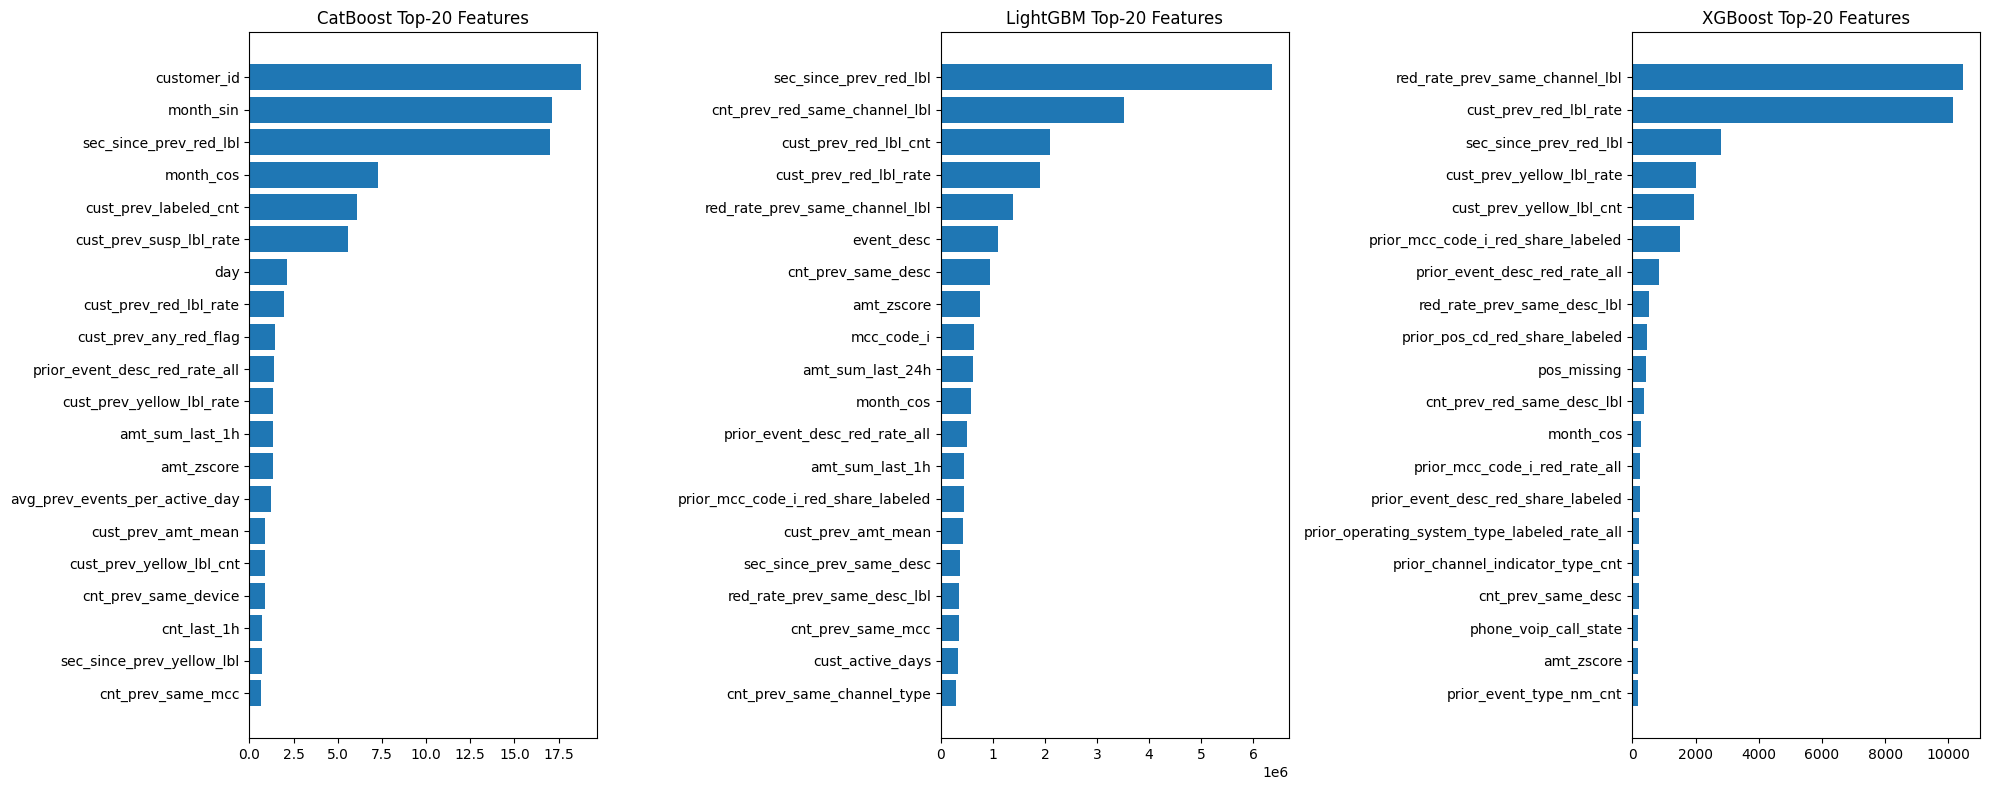

In [18]:
# ==================== FEATURE IMPORTANCE ====================
import matplotlib.pyplot as plt

# Reload models for importance analysis
model_cb = CatBoostClassifier().load_model(str(BOOST_CACHE_DIR / "cb_main.cbm"))
cb_imp = model_cb.get_feature_importance()
cb_feat_imp = pd.DataFrame({"feature": feature_cols, "importance": cb_imp}).sort_values("importance", ascending=False)

model_lgb_imp = lgb.Booster(model_file=str(BOOST_CACHE_DIR / "lgb_main.txt"))
lgb_imp_raw = model_lgb_imp.feature_importance(importance_type="gain")
lgb_feat_imp = pd.DataFrame({"feature": feature_cols, "importance": lgb_imp_raw}).sort_values("importance", ascending=False)

model_xgb_imp = xgb.Booster()
model_xgb_imp.load_model(str(BOOST_CACHE_DIR / "xgb_main.json"))
xgb_imp_dict = model_xgb_imp.get_score(importance_type="gain")
xgb_feat_imp = pd.DataFrame([
    {"feature": f, "importance": xgb_imp_dict.get(f, 0.0)} for f in feature_cols
]).sort_values("importance", ascending=False)

del model_cb, model_lgb_imp, model_xgb_imp; gc.collect()

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, df_imp, title in zip(axes, [cb_feat_imp, lgb_feat_imp, xgb_feat_imp], ["CatBoost", "LightGBM", "XGBoost"]):
    top = df_imp.head(20)
    ax.barh(top["feature"].values[::-1], top["importance"].values[::-1])
    ax.set_title(f"{title} Top-20 Features")
plt.tight_layout()
plt.show()

In [19]:
# ==================== RESULTS TABLE ====================

results = pd.DataFrame({
    "Model": [
        "CatBoost Main", "CatBoost Blend",
        "LightGBM Main", "LightGBM Blend",
        "XGBoost Main", "XGBoost Blend",
        "Meta-Blend (rank-space)",
    ],
    "Val PR-AUC": [
        ap_cb_main, best_ap_cb,
        ap_lgb_main, best_ap_lgb,
        ap_xgb_main, best_ap_xgb,
        best_meta_ap,
    ],
})
results["Val PR-AUC"] = results["Val PR-AUC"].apply(lambda x: f"{x:.6f}")
print(results.to_string(index=False))

print(f"\nCatBoost blend weights:  { {blend_keys_cb[i]: round(float(best_w_cb[i]), 4) for i in range(len(blend_keys_cb))} }")
print(f"LightGBM blend weights:  { {blend_keys_lgb[i]: round(float(best_w_lgb[i]), 4) for i in range(len(blend_keys_lgb))} }")
print(f"XGBoost blend weights:   { {blend_keys_xgb[i]: round(float(best_w_xgb[i]), 4) for i in range(len(blend_keys_xgb))} }")
print(f"Meta-blend weights:      { {blend_keys_meta[i]: round(float(best_meta_w[i]), 4) for i in range(len(blend_keys_meta))} }")

                  Model Val PR-AUC
          CatBoost Main   0.453295
         CatBoost Blend   0.456767
          LightGBM Main   0.480484
         LightGBM Blend   0.483116
           XGBoost Main   0.468155
          XGBoost Blend   0.461559
Meta-Blend (rank-space)   0.474974

CatBoost blend weights:  {'main': 0.5353, 'recent': 0.048, 'product': 0.4166}
LightGBM blend weights:  {'main': 0.186, 'recent': 0.0031, 'product': 0.8108}
XGBoost blend weights:   {'main': 0.3333, 'recent': 0.3333, 'product': 0.3333}
Meta-blend weights:      {'catboost': 0.3334, 'lightgbm': 0.3334, 'xgboost': 0.3332}


In [20]:
# ==================== GRID SEARCH WEIGHT OPTIMIZATION + NEW SUBMISSIONS ====================

import time as _time

GRID_STEP = 0.01  # шаг сетки (0.02 = 1326 комбинаций на бленд, ~2-3 сек)

def grid_search_blend_3(heads_dict, y_true, step=GRID_STEP):
    """Полный перебор весов для 3 голов (w1 + w2 + w3 = 1)."""
    keys = list(heads_dict.keys())
    preds = [heads_dict[k] for k in keys]
    best_ap, best_w = -1.0, np.array([1/3]*3, dtype=np.float32)
    for w0 in np.arange(0, 1 + step/2, step):
        for w1 in np.arange(0, 1 - w0 + step/2, step):
            w2 = 1.0 - w0 - w1
            if w2 < -1e-6:
                continue
            w2 = max(0.0, w2)
            blend = w0 * preds[0] + w1 * preds[1] + w2 * preds[2]
            ap = average_precision_score(y_true, blend)
            if ap > best_ap:
                best_ap = ap
                best_w = np.array([w0, w1, w2], dtype=np.float32)
    return keys, best_w, float(best_ap)

_t0 = _time.time()

# ==================== 1. PER-BOOSTER GRID SEARCH ====================
print("=" * 60)
print(f"GRID SEARCH: Per-booster blend (step={GRID_STEP})")
print("=" * 60)

# Product sub-model predictions (val)
_cb_prod_v  = logit(sigmoid(pred_cb_susp_val) * sigmoid(pred_cb_rg_val))
_lgb_prod_v = logit(np.clip(pred_lgb_susp_val, 1e-8, 1-1e-8) * np.clip(pred_lgb_rg_val, 1e-8, 1-1e-8))
_xgb_prod_v = logit(np.clip(pred_xgb_susp_val, 1e-8, 1-1e-8) * np.clip(pred_xgb_rg_val, 1e-8, 1-1e-8))

# Rank-space heads (val)
hv = {
    "cb":  {"main": rank_norm(pred_cb_main_val),  "recent": rank_norm(pred_cb_recent_val),  "product": rank_norm(_cb_prod_v)},
    "lgb": {"main": rank_norm(pred_lgb_main_val), "recent": rank_norm(pred_lgb_recent_val), "product": rank_norm(_lgb_prod_v)},
    "xgb": {"main": rank_norm(pred_xgb_main_val), "recent": rank_norm(pred_xgb_recent_val), "product": rank_norm(_xgb_prod_v)},
}

gs = {}
for tag in ["cb", "lgb", "xgb"]:
    gs[tag] = grid_search_blend_3(hv[tag], y_main_val)

for tag, label in [("cb", "CatBoost"), ("lgb", "LightGBM"), ("xgb", "XGBoost")]:
    ks, ws, ap = gs[tag]
    print(f"  {label:10s}: {dict(zip(ks, ws.round(4).tolist()))}  ->  PR-AUC = {ap:.6f}")

# Blended val predictions
bv = {}
for tag in ["cb", "lgb", "xgb"]:
    ks, ws, _ = gs[tag]
    bv[tag] = sum(ws[i] * hv[tag][ks[i]] for i in range(3))

# ==================== 2. META-BLEND GRID SEARCH ====================
print()
hv_meta = {"catboost": rank_norm(bv["cb"]), "lightgbm": rank_norm(bv["lgb"]), "xgboost": rank_norm(bv["xgb"])}
gk_meta, gw_meta, gap_meta = grid_search_blend_3(hv_meta, y_main_val)
print(f"  {'META':10s}: {dict(zip(gk_meta, gw_meta.round(4).tolist()))}  ->  PR-AUC = {gap_meta:.6f}")
print(f"\n  Grid search done in {_time.time() - _t0:.1f}s")

# ==================== 3. TEST PREDICTIONS ====================
print("\n" + "=" * 60)
print("TEST PREDICTIONS (loading models from cache)")
print("=" * 60)

# Feature names from saved CatBoost model
_m0 = CatBoostClassifier()
_m0.load_model(str(BOOST_CACHE_DIR / "cb_main.cbm"))
_fnames = _m0.feature_names_
_ccols = [c for c in _fnames if c in set(CAT_COLS)]
del _m0; gc.collect()

# Check features exist in test_df
_missing = [f for f in _fnames if f not in test_df.columns]
if _missing:
    print(f"  WARNING: {len(_missing)} features missing: {_missing[:5]}...")
print(f"  {len(_fnames)} features, {len(_ccols)} cat")

_Xt = test_df[_fnames]

# --- CatBoost (load one at a time) ---
tp = {"cb": {}, "lgb": {}, "xgb": {}}
_pool = Pool(_Xt, cat_features=_ccols)
for sub in ["main", "recent", "susp", "rg"]:
    _m = CatBoostClassifier()
    _m.load_model(str(BOOST_CACHE_DIR / f"cb_{sub}.cbm"))
    tp["cb"][sub] = _m.predict(_pool, prediction_type="RawFormulaVal")
    del _m
gc.collect(); del _pool; gc.collect()
print("  CatBoost done")

# --- LightGBM ---
_Xt_lgb = _lgb_prepare(_Xt, _ccols)
for sub in ["main", "recent", "susp", "rg"]:
    _m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / f"lgb_{sub}.txt"))
    tp["lgb"][sub] = _m.predict(_Xt_lgb)
    del _m
gc.collect(); del _Xt_lgb; gc.collect()
print("  LightGBM done")

# --- XGBoost ---
_dtest = xgb.DMatrix(_Xt)
for sub in ["main", "recent", "susp", "rg"]:
    _m = xgb.Booster()
    _m.load_model(str(BOOST_CACHE_DIR / f"xgb_{sub}.json"))
    tp["xgb"][sub] = _m.predict(_dtest)
    del _m
gc.collect(); del _dtest, _Xt; gc.collect()
print("  XGBoost done")

# ==================== 4. APPLY BLEND WEIGHTS ====================
# Product sub-models (test)
tp_prod = {
    "cb":  logit(sigmoid(tp["cb"]["susp"]) * sigmoid(tp["cb"]["rg"])),
    "lgb": logit(np.clip(tp["lgb"]["susp"], 1e-8, 1-1e-8) * np.clip(tp["lgb"]["rg"], 1e-8, 1-1e-8)),
    "xgb": logit(np.clip(tp["xgb"]["susp"], 1e-8, 1-1e-8) * np.clip(tp["xgb"]["rg"], 1e-8, 1-1e-8)),
}

# Per-booster rank-space blends (test)
ht = {}
for tag in ["cb", "lgb", "xgb"]:
    ht[tag] = {"main": rank_norm(tp[tag]["main"]), "recent": rank_norm(tp[tag]["recent"]), "product": rank_norm(tp_prod[tag])}

bt = {}
for tag in ["cb", "lgb", "xgb"]:
    ks, ws, _ = gs[tag]
    bt[tag] = sum(ws[i] * ht[tag][ks[i]] for i in range(3))

# Meta-blend (test)
ht_meta = {"catboost": rank_norm(bt["cb"]), "lightgbm": rank_norm(bt["lgb"]), "xgboost": rank_norm(bt["xgb"])}
final_pred = sum(gw_meta[i] * ht_meta[gk_meta[i]] for i in range(3))

# ==================== 5. SAVE SUBMISSIONS ====================
print("\n" + "=" * 60)
print("SAVING SUBMISSIONS")
print("=" * 60)

sample_sub = pd.read_csv(DATA_DIR / "sample_submit.csv")
_eids = test_df["event_id"].values

def _save_sub(predict, name):
    pdf = pd.DataFrame({"event_id": _eids, "predict": predict})
    sub = sample_sub[["event_id"]].merge(pdf, on="event_id", how="left")
    miss = int(sub["predict"].isna().sum())
    assert miss == 0, f"{name}: {miss} missing event_ids!"
    path = SUBMISSION_DIR / f"submission_{name}.csv"
    sub = sub.drop_duplicates(subset="event_id", keep="first")
    sub.to_csv(path, index=False)
    print(f"  {path.name} ({len(sub)} rows)")

_save_sub(final_pred, "gs_meta_blend")
_save_sub(bt["cb"],   "gs_catboost_only")
_save_sub(bt["lgb"],  "gs_lightgbm_only")
_save_sub(bt["xgb"],  "gs_xgboost_only")

print(f"\nTotal time: {_time.time() - _t0:.1f}s")

GRID SEARCH: Per-booster blend (step=0.01)


KeyboardInterrupt: 

In [21]:
# ==================== GRID SEARCH OPTIMIZATION + NEW SUBMISSIONS ====================

import time as _time

GRID_STEP = 0.01  # 0.02 = ~1 мин, 0.01 = ~3-5 мин

def _fast_ap(y_true, y_score):
    """PR-AUC через numpy (в 4x быстрее sklearn)."""
    desc = np.argsort(y_score)[::-1]
    y_sorted = y_true[desc]
    tp = np.cumsum(y_sorted)
    n_pos = tp[-1]
    if n_pos == 0:
        return 0.0
    prec = tp / np.arange(1, len(y_sorted) + 1)
    return float(np.sum(prec * y_sorted) / n_pos)

def grid_search_blend_3(heads_dict, y_true, step=GRID_STEP):
    """Grid search: 3 weights summing to 1, iterative (no OOM)."""
    keys = list(heads_dict.keys())
    p0, p1, p2 = heads_dict[keys[0]], heads_dict[keys[1]], heads_dict[keys[2]]
    y_np = np.asarray(y_true, dtype=np.int8)

    best_ap, best_w = -1.0, np.array([1/3]*3, dtype=np.float32)
    grid = np.arange(0, 1 + step/2, step)

    for w0 in grid:
        for w1 in grid:
            w2 = 1.0 - w0 - w1
            if w2 < -1e-6:
                break
            w2 = max(0.0, w2)
            blend = w0 * p0 + w1 * p1 + w2 * p2
            ap = _fast_ap(y_np, blend)
            if ap > best_ap:
                best_ap = ap
                best_w = np.array([w0, w1, w2], dtype=np.float32)

    return keys, best_w, float(best_ap)

_t0 = _time.time()

# ==================== 1. PER-BOOSTER GRID SEARCH ====================
print("=" * 60)
print(f"GRID SEARCH: Per-booster blend (step={GRID_STEP})")
print("=" * 60)

# Product sub-model predictions (val)
_cb_prod_v  = logit(sigmoid(pred_cb_susp_val) * sigmoid(pred_cb_rg_val))
_lgb_prod_v = logit(np.clip(pred_lgb_susp_val, 1e-8, 1-1e-8) * np.clip(pred_lgb_rg_val, 1e-8, 1-1e-8))
_xgb_prod_v = logit(np.clip(pred_xgb_susp_val, 1e-8, 1-1e-8) * np.clip(pred_xgb_rg_val, 1e-8, 1-1e-8))

hv = {
    "cb":  {"main": rank_norm(pred_cb_main_val),  "recent": rank_norm(pred_cb_recent_val),  "product": rank_norm(_cb_prod_v)},
    "lgb": {"main": rank_norm(pred_lgb_main_val), "recent": rank_norm(pred_lgb_recent_val), "product": rank_norm(_lgb_prod_v)},
    "xgb": {"main": rank_norm(pred_xgb_main_val), "recent": rank_norm(pred_xgb_recent_val), "product": rank_norm(_xgb_prod_v)},
}

gs = {}
for tag, label in [("cb", "CatBoost"), ("lgb", "LightGBM"), ("xgb", "XGBoost")]:
    _t1 = _time.time()
    gs[tag] = grid_search_blend_3(hv[tag], y_main_val)
    ks, ws, ap = gs[tag]
    print(f"  {label:10s}: {dict(zip(ks, ws.round(4).tolist()))}  ->  PR-AUC = {ap:.6f}  ({_time.time()-_t1:.1f}s)")

# Per-booster blended val
bv = {}
for tag in ["cb", "lgb", "xgb"]:
    ks, ws, _ = gs[tag]
    bv[tag] = sum(ws[i] * hv[tag][ks[i]] for i in range(3))

# ==================== 2. META-BLEND GRID SEARCH ====================
print()
hv_meta = {"catboost": rank_norm(bv["cb"]), "lightgbm": rank_norm(bv["lgb"]), "xgboost": rank_norm(bv["xgb"])}
_t1 = _time.time()
gk_meta, gw_meta, gap_meta = grid_search_blend_3(hv_meta, y_main_val)
print(f"  {'META':10s}: {dict(zip(gk_meta, gw_meta.round(4).tolist()))}  ->  PR-AUC = {gap_meta:.6f}  ({_time.time()-_t1:.1f}s)")
print(f"\n  Total grid search: {_time.time() - _t0:.1f}s")

# ==================== 3. TEST PREDICTIONS ====================
print("\n" + "=" * 60)
print("TEST PREDICTIONS (loading models from cache)")
print("=" * 60)

# Feature names from saved model
_m0 = CatBoostClassifier()
_m0.load_model(str(BOOST_CACHE_DIR / "cb_main.cbm"))
_fnames = _m0.feature_names_
_ccols = [c for c in _fnames if c in set(CAT_COLS)]
del _m0; gc.collect()
print(f"  {len(_fnames)} features, {len(_ccols)} cat")

_Xt = test_df[_fnames]

# --- CatBoost ---
tp = {"cb": {}, "lgb": {}, "xgb": {}}
_pool = Pool(_Xt, cat_features=_ccols)
for sub in ["main", "recent", "susp", "rg"]:
    _m = CatBoostClassifier()
    _m.load_model(str(BOOST_CACHE_DIR / f"cb_{sub}.cbm"))
    tp["cb"][sub] = _m.predict(_pool, prediction_type="RawFormulaVal")
    del _m
gc.collect(); del _pool; gc.collect()
print("  CatBoost done")

# --- LightGBM ---
_Xt_lgb = _lgb_prepare(_Xt, _ccols)
for sub in ["main", "recent", "susp", "rg"]:
    _m = lgb.Booster(model_file=str(BOOST_CACHE_DIR / f"lgb_{sub}.txt"))
    tp["lgb"][sub] = _m.predict(_Xt_lgb)
    del _m
gc.collect(); del _Xt_lgb; gc.collect()
print("  LightGBM done")

# --- XGBoost ---
_dtest = xgb.DMatrix(_Xt)
for sub in ["main", "recent", "susp", "rg"]:
    _m = xgb.Booster()
    _m.load_model(str(BOOST_CACHE_DIR / f"xgb_{sub}.json"))
    tp["xgb"][sub] = _m.predict(_dtest)
    del _m
gc.collect(); del _dtest, _Xt; gc.collect()
print("  XGBoost done")

# ==================== 4. APPLY BLEND WEIGHTS ====================
tp_prod = {
    "cb":  logit(sigmoid(tp["cb"]["susp"]) * sigmoid(tp["cb"]["rg"])),
    "lgb": logit(np.clip(tp["lgb"]["susp"], 1e-8, 1-1e-8) * np.clip(tp["lgb"]["rg"], 1e-8, 1-1e-8)),
    "xgb": logit(np.clip(tp["xgb"]["susp"], 1e-8, 1-1e-8) * np.clip(tp["xgb"]["rg"], 1e-8, 1-1e-8)),
}

ht = {}
for tag in ["cb", "lgb", "xgb"]:
    ht[tag] = {"main": rank_norm(tp[tag]["main"]), "recent": rank_norm(tp[tag]["recent"]), "product": rank_norm(tp_prod[tag])}

bt = {}
for tag in ["cb", "lgb", "xgb"]:
    ks, ws, _ = gs[tag]
    bt[tag] = sum(ws[i] * ht[tag][ks[i]] for i in range(3))

ht_meta = {"catboost": rank_norm(bt["cb"]), "lightgbm": rank_norm(bt["lgb"]), "xgboost": rank_norm(bt["xgb"])}
final_pred = sum(gw_meta[i] * ht_meta[gk_meta[i]] for i in range(3))

# ==================== 5. SAVE SUBMISSIONS ====================
print("\n" + "=" * 60)
print("SAVING SUBMISSIONS")
print("=" * 60)

sample_sub = pd.read_csv(DATA_DIR / "sample_submit.csv")
_eids = test_df["event_id"].values

def _save_sub(predict, name):
    pdf = pd.DataFrame({"event_id": _eids, "predict": predict})
    sub = sample_sub[["event_id"]].merge(pdf, on="event_id", how="left")
    miss = int(sub["predict"].isna().sum())
    assert miss == 0, f"{name}: {miss} missing!"
    path = SUBMISSION_DIR / f"submission_{name}.csv"
    sub = sub.drop_duplicates(subset="event_id", keep="first")
    sub.to_csv(path, index=False)
    print(f"  {path.name} ({len(sub)} rows)")

_save_sub(final_pred, "gs_meta_blend")
_save_sub(bt["cb"],   "gs_catboost")
_save_sub(bt["lgb"],  "gs_lightgbm")
_save_sub(bt["xgb"],  "gs_xgboost")

print(f"\nTotal time: {_time.time() - _t0:.1f}s")

GRID SEARCH: Per-booster blend (step=0.01)
  CatBoost  : {'main': 0.46000000834465027, 'recent': 0.029999999329447746, 'product': 0.5099999904632568}  ->  PR-AUC = 0.456912  (228.7s)
  LightGBM  : {'main': 0.44999998807907104, 'recent': 0.0, 'product': 0.550000011920929}  ->  PR-AUC = 0.483345  (235.1s)
  XGBoost   : {'main': 0.4300000071525574, 'recent': 0.0, 'product': 0.5699999928474426}  ->  PR-AUC = 0.475451  (229.1s)

  META      : {'catboost': 0.019999999552965164, 'lightgbm': 0.7099999785423279, 'xgboost': 0.27000001072883606}  ->  PR-AUC = 0.485030  (228.5s)

  Total grid search: 923.3s

TEST PREDICTIONS (loading models from cache)
  159 features, 17 cat
  CatBoost done
  LightGBM done
  XGBoost done

SAVING SUBMISSIONS
  submission_gs_meta_blend.csv (633683 rows)
  submission_gs_catboost.csv (633683 rows)
  submission_gs_lightgbm.csv (633683 rows)
  submission_gs_xgboost.csv (633683 rows)

Total time: 968.5s
